In [2]:
from pathlib import Path
import os

os.chdir("/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework")
print(Path.cwd())

/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework


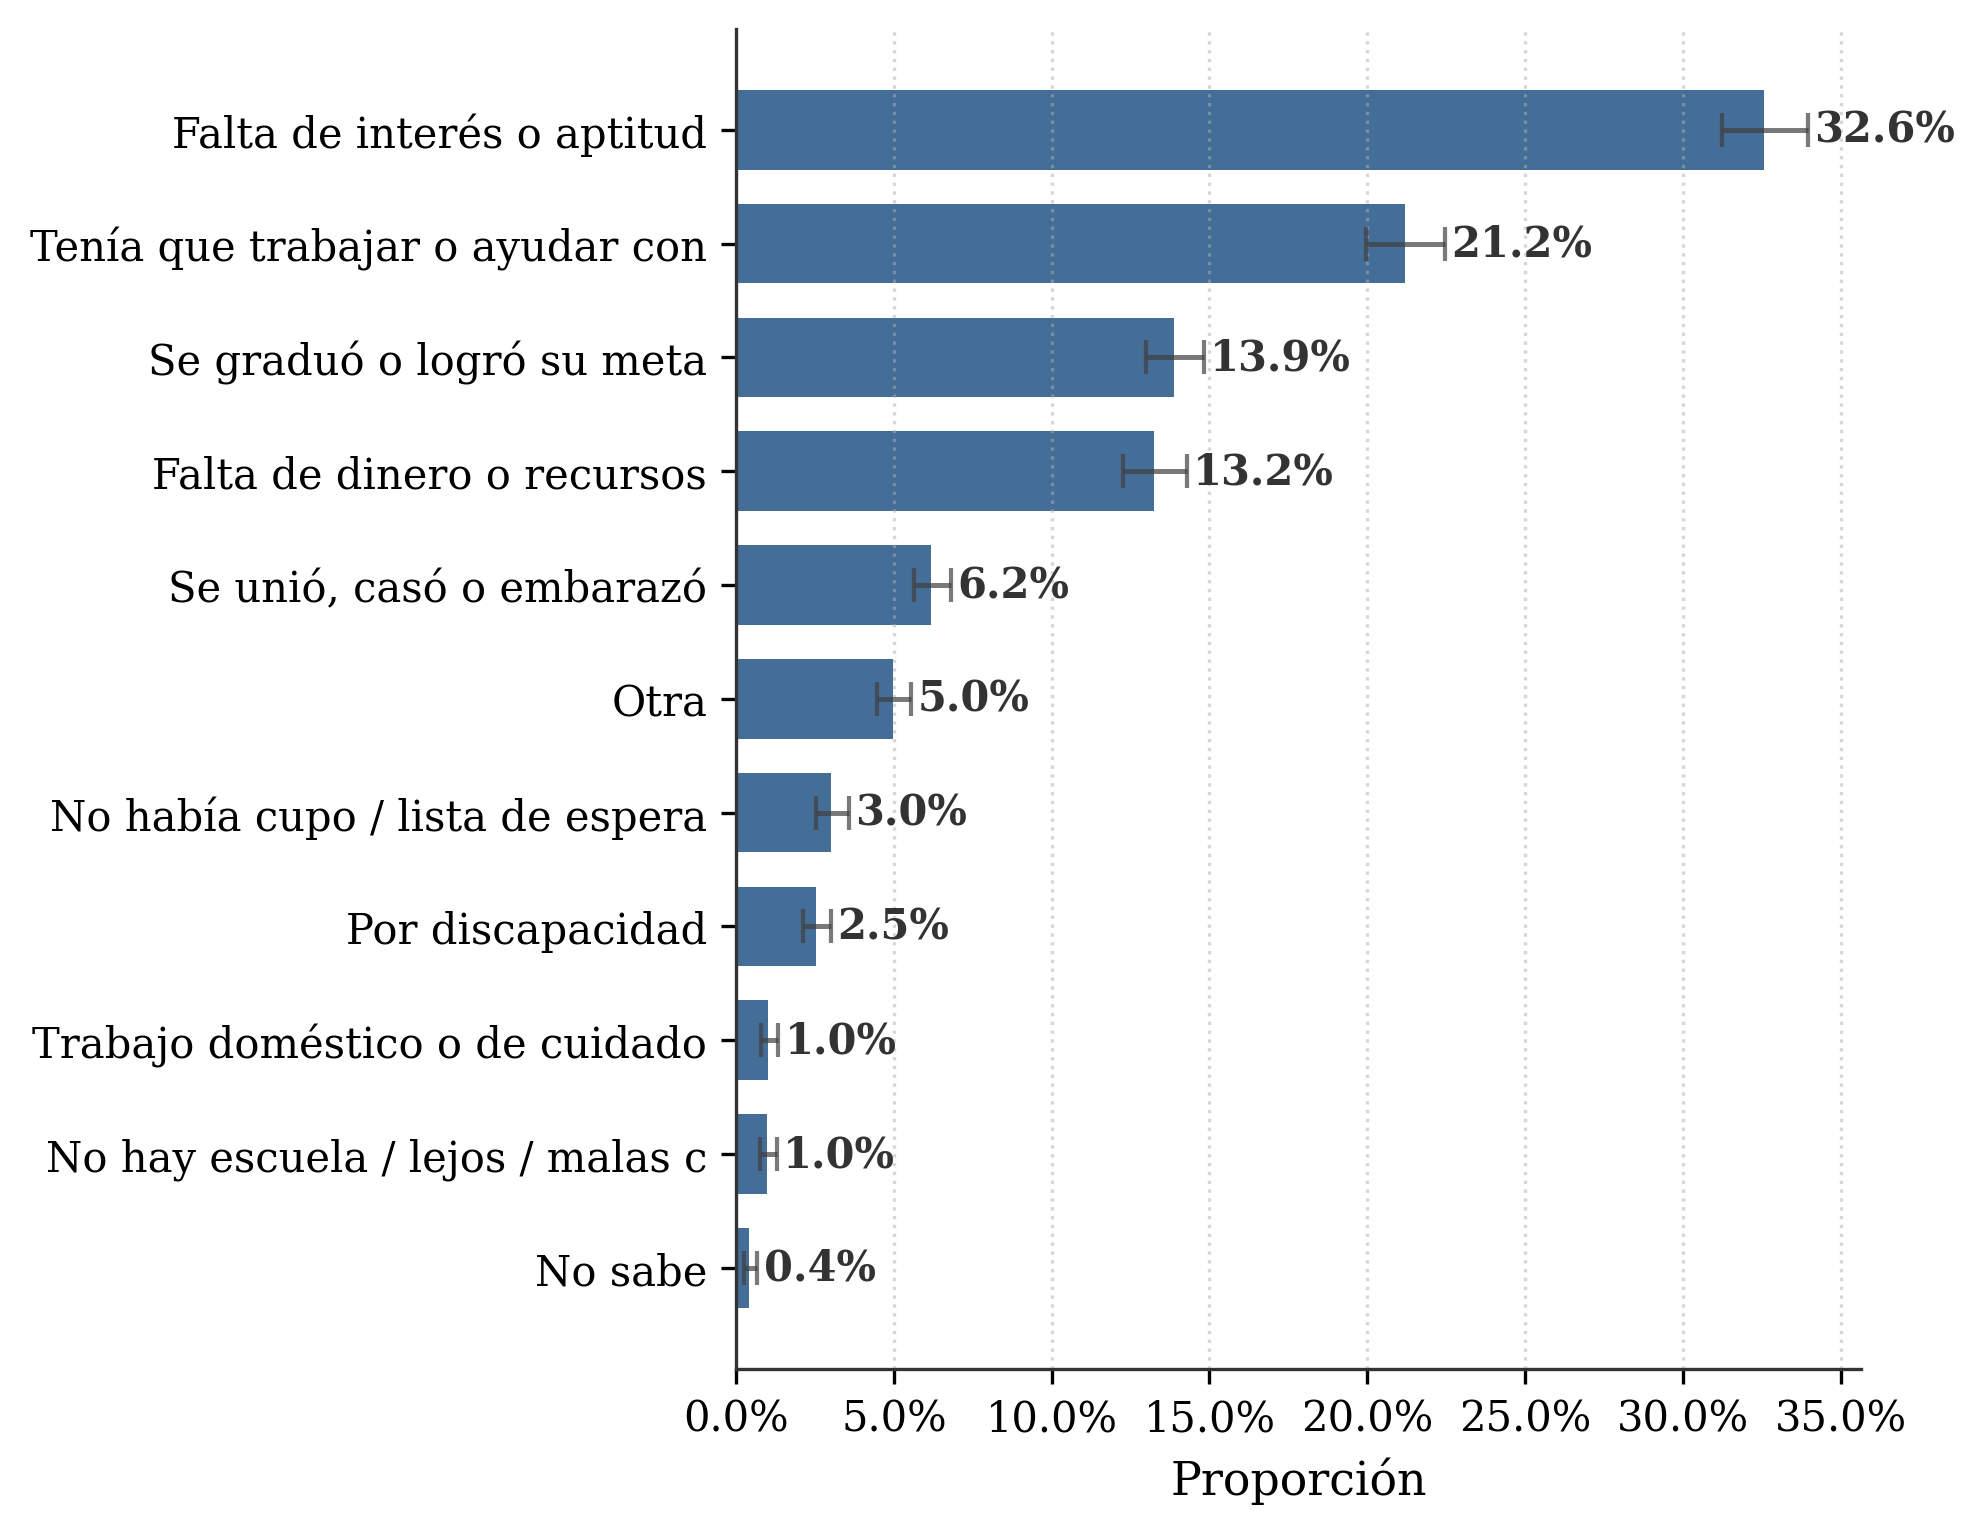

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter

# =============================================
# NÚMERO DE FIGURA (cambiar según corresponda)
# =============================================
FIG_NUM = '3.1'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',          # Fuente serif (Times)
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "No asistencia escolar"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

df.rename(columns={
    "anio": "Anio",
    "razon": "Razon",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# =============================================
# PREPARACIÓN DE ERRORES Y ORDEN
# =============================================
df['Error_xerr_neg'] = df['Media'] - df['IC_inf']
df['Error_xerr_pos'] = df['IC_sup'] - df['Media']
df_sorted = df.sort_values(by='Media', ascending=True).reset_index(drop=True)

# =============================================
# CONSTRUCCIÓN DE LA FIGURA (una sola gráfica)
# =============================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Color único para todas las barras (serie única)
color_barra = '#2F5D8C'

# Barras horizontales con intervalo de confianza
bars = ax.barh(
    y=df_sorted['Razon'],
    width=df_sorted['Media'],
    color=color_barra,
    height=0.7,
    alpha=0.9,
    xerr=[df_sorted['Error_xerr_neg'], df_sorted['Error_xerr_pos']],
    capsize=4,
    error_kw={'ecolor': '#404040', 'linewidth': 1.2, 'alpha': 0.7}
)

# =============================================
# ESTILO DE EJES Y REJILLA
# =============================================
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Rejilla solo en eje X (según estilo unificado)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Eliminar spines superiores y derecho (opcional, para limpieza)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Mantener spines izquierdo e inferior
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Etiqueta del eje X
ax.set_xlabel('Proporción')

# Ajuste de marcas del eje Y
ax.tick_params(axis='y', labelsize=10)

# =============================================
# ETIQUETAS DE VALORES AL FINAL DE CADA BARRA
# =============================================
for i, bar in enumerate(bars):
    width = bar.get_width()
    error_pos = df_sorted['Error_xerr_pos'].iloc[i]
    x_pos = width + error_pos + 0.002
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2.0,
        f'{width:.1%}',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

# (Opcional) Mostrar la figura
plt.show()

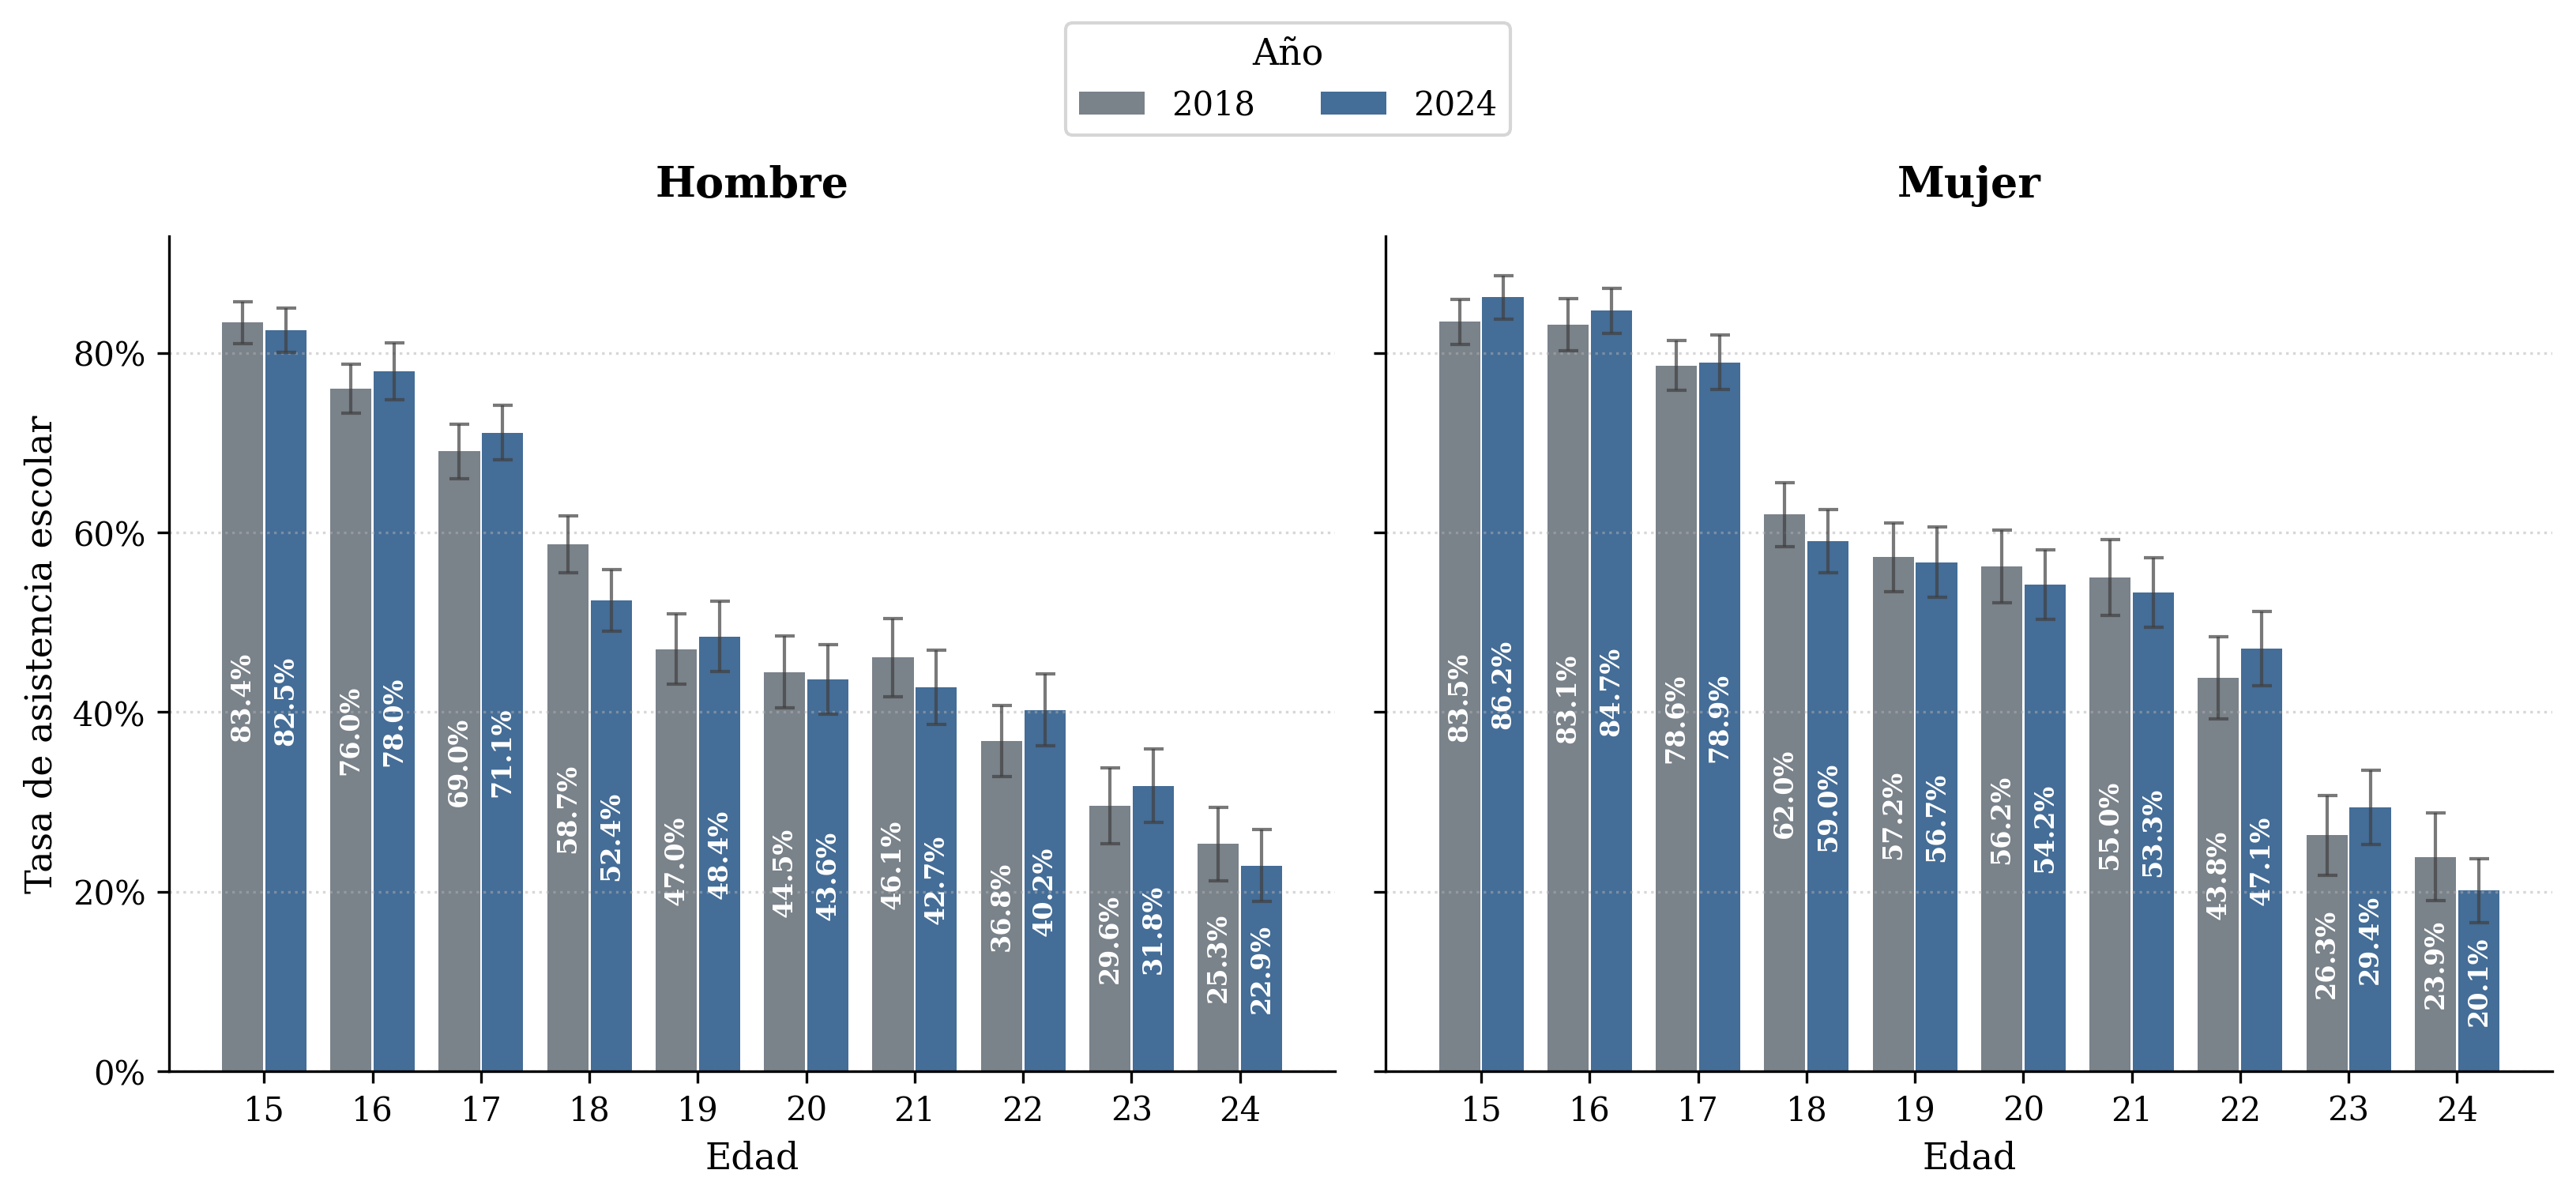

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.2'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 13,          # CAMBIO
    'axes.titleweight': 'bold',    # CAMBIO
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,   # CAMBIO
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades y sexo"

df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(
        c for c in unicodedata.normalize("NFD", col)
        if unicodedata.category(c) != "Mn"
    )
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

renombres = {
    'anio': 'Anio',
    'sexo': 'Sexo',
    'edad': 'Edad',
    'media': 'Media',
    'error_estandar_linealizado': 'Error',
    'intervalo_de_confianza_inferior': 'IC_inf',
    'intervalo_de_confianza_superior': 'IC_sup'
}

df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# =============================================
# PREPARACIÓN DE DATOS POR SEXO
# =============================================
sexos = ["Hombre", "Mujer"]

anios_ordenados = sorted(df['Anio'].unique())

colores_anios = {
    anios_ordenados[0]: '#6C757D',
    anios_ordenados[1]: '#2F5D8C'
}

# =============================================
# CREACIÓN DE SUBPLOTS
# =============================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),      # CAMBIO
    sharey=True
)

for ax, sexo in zip(axes, sexos):

    dff = df[df['Sexo'].str.lower().str.contains(sexo.lower())].copy()
    dff = dff.sort_values(['Edad', 'Anio'])

    edades = sorted(dff['Edad'].unique())
    anios = sorted(dff['Anio'].unique())

    n_anios = len(anios)

    # =============================================
    # BARRAS MÁS ANCHAS
    # =============================================
    ancho_barra = 0.80          # CAMBIO (antes 0.35)
    ancho_individual = ancho_barra / n_anios

    offsets = np.linspace(
        -ancho_barra/2 + ancho_individual/2,
        ancho_barra/2 - ancho_individual/2,
        n_anios
    )

    x_pos = np.arange(len(edades))

    for i, anio in enumerate(anios):

        sub = dff[dff['Anio'] == anio].set_index('Edad').loc[edades]

        err_neg = sub['Media'] - sub['IC_inf']
        err_pos = sub['IC_sup'] - sub['Media']

        x = x_pos + offsets[i]

        bars = ax.bar(
            x,
            sub['Media'],
            width=ancho_individual*0.95,   # CAMBIO
            color=colores_anios[anio],
            alpha=0.9,
            label=str(anio),
            yerr=[err_neg, err_pos],
            capsize=3,
            error_kw={
                'ecolor': '#404040',
                'linewidth': 1.0,
                'alpha': 0.7
            }
        )

        for bar, media in zip(bars, sub['Media']):

            if media > 0:

                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    media/2,
                    f'{media*100:.1f}%',
                    ha='center',
                    va='center',
                    rotation=90,
                    color='white',
                    fontsize=8,
                    fontweight='bold'
                )

    # =============================================
    # TÍTULO DEL SUBPLOT
    # =============================================
    ax.set_title(sexo, pad=12)      # CAMBIO

    ax.set_xticks(x_pos)
    ax.set_xticklabels(edades)

    ax.set_xlabel("Edad")

    if sexo == "Hombre":
        ax.set_ylabel("Tasa de asistencia escolar")

    ax.yaxis.set_major_formatter(PercentFormatter(1))

    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =============================================
# LEYENDA GENERAL (ARRIBA CENTRADA)
# =============================================
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Año',
    ncol=len(labels),          # una columna por año
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# GUARDADO
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'),
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'),
    bbox_inches='tight'
)

plt.show()

In [39]:
# ==============================
# PRUEBA DE DIFERENCIAS POR SEXO
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata
import dataframe_image as dfi

# ==========================================
# 1. CARGAR DATOS
# ==========================================

ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades y sexo"

df = pd.read_excel(ruta, sheet_name=hoja)

# ==========================================
# 2. LIMPIAR NOMBRES DE COLUMNAS
# ==========================================

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(
        c for c in unicodedata.normalize("NFD", col)
        if unicodedata.category(c) != "Mn"
    )
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas de acuerdo con el archivo Excel
renombres = {
    "anio": "Anio",
    "edad": "Edad",
    "sexo": "Sexo",
    "media": "Asiste",
    "error_estandar_linealizado": "Se",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}

df.rename(columns=renombres, inplace=True)

print("✅ Columnas detectadas:")
print(df.columns.tolist())

# Verificar columnas necesarias
columnas_necesarias = ["Anio", "Edad", "Sexo", "Asiste", "Se"]

faltantes = [c for c in columnas_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# ==========================================
# 3. PRUEBA DE DIFERENCIA DE PROPORCIONES
# ==========================================

resultados = []

for (anio, edad), grupo in df.groupby(["Anio", "Edad"]):

    # Debe haber dos sexos
    if grupo["Sexo"].nunique() < 2:
        continue

    # Detectar hombres y mujeres
    hombres = grupo[
        grupo["Sexo"].astype(str).str.contains("hom", case=False, na=False)
    ]

    mujeres = grupo[
        grupo["Sexo"].astype(str).str.contains("muj", case=False, na=False)
    ]

    if hombres.empty or mujeres.empty:
        continue

    # Proporciones
    ph = hombres["Asiste"].iloc[0]
    pm = mujeres["Asiste"].iloc[0]

    # Errores estándar
    sh = hombres["Se"].iloc[0]
    sm = mujeres["Se"].iloc[0]

    # Diferencia Hombre - Mujer
    diff = ph - pm

    # Error estándar combinado
    se_comb = np.sqrt(sh**2 + sm**2)

    # Estadístico Z
    z = diff / se_comb if se_comb > 0 else np.nan

    # Valor p bilateral
    p = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    # Intervalo de confianza
    ci_inf = diff - 1.96 * se_comb
    ci_sup = diff + 1.96 * se_comb

    resultados.append({
        "Anio": anio,
        "Edad": edad,
        "Asistencia Hombres": ph,
        "Asistencia Mujeres": pm,
        "Diferencia (H-M)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p,
        "IC95% inferior": ci_inf,
        "IC95% superior": ci_sup,
        "Decisión": (
            "Rechazo H0"
            if (not np.isnan(p) and p < 0.05)
            else "No rechazo H0"
        )
    })

# ==========================================
# 4. TABLA DE RESULTADOS
# ==========================================

res_df_1 = pd.DataFrame(resultados)

res_df_1 = res_df_1.sort_values(["Anio", "Edad"]).reset_index(drop=True)

styled = (
    res_df_1.style
    .format({
        "Asistencia Hombres": "{:.2%}",
        "Asistencia Mujeres": "{:.2%}",
        "Diferencia (H-M)": "{:.2%}",
        "Error Estándar": "{:.4f}",
        "Z": "{:.2f}",
        "Valor-p": "{:.4f}",
        "IC95% inferior": "{:.2%}",
        "IC95% superior": "{:.2%}",
    })
    .map(
        lambda x:
            "background-color: lightgreen; color:black"
            if x == "Rechazo H0"
            else (
                "background-color: salmon; color:black"
                if x == "No rechazo H0"
                else ""
            ),
        subset=["Decisión"]
    )
    .background_gradient(
        subset=["Valor-p"],
        cmap="RdYlGn_r"
    )
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
            ],
        },
        {
            "selector": "td",
            "props": [("padding", "6px")],
        },
    ])
)



✅ Columnas detectadas:
['Anio', 'Sexo', 'Edad', 'Asiste', 'Se', 'IC_inf', 'IC_sup']


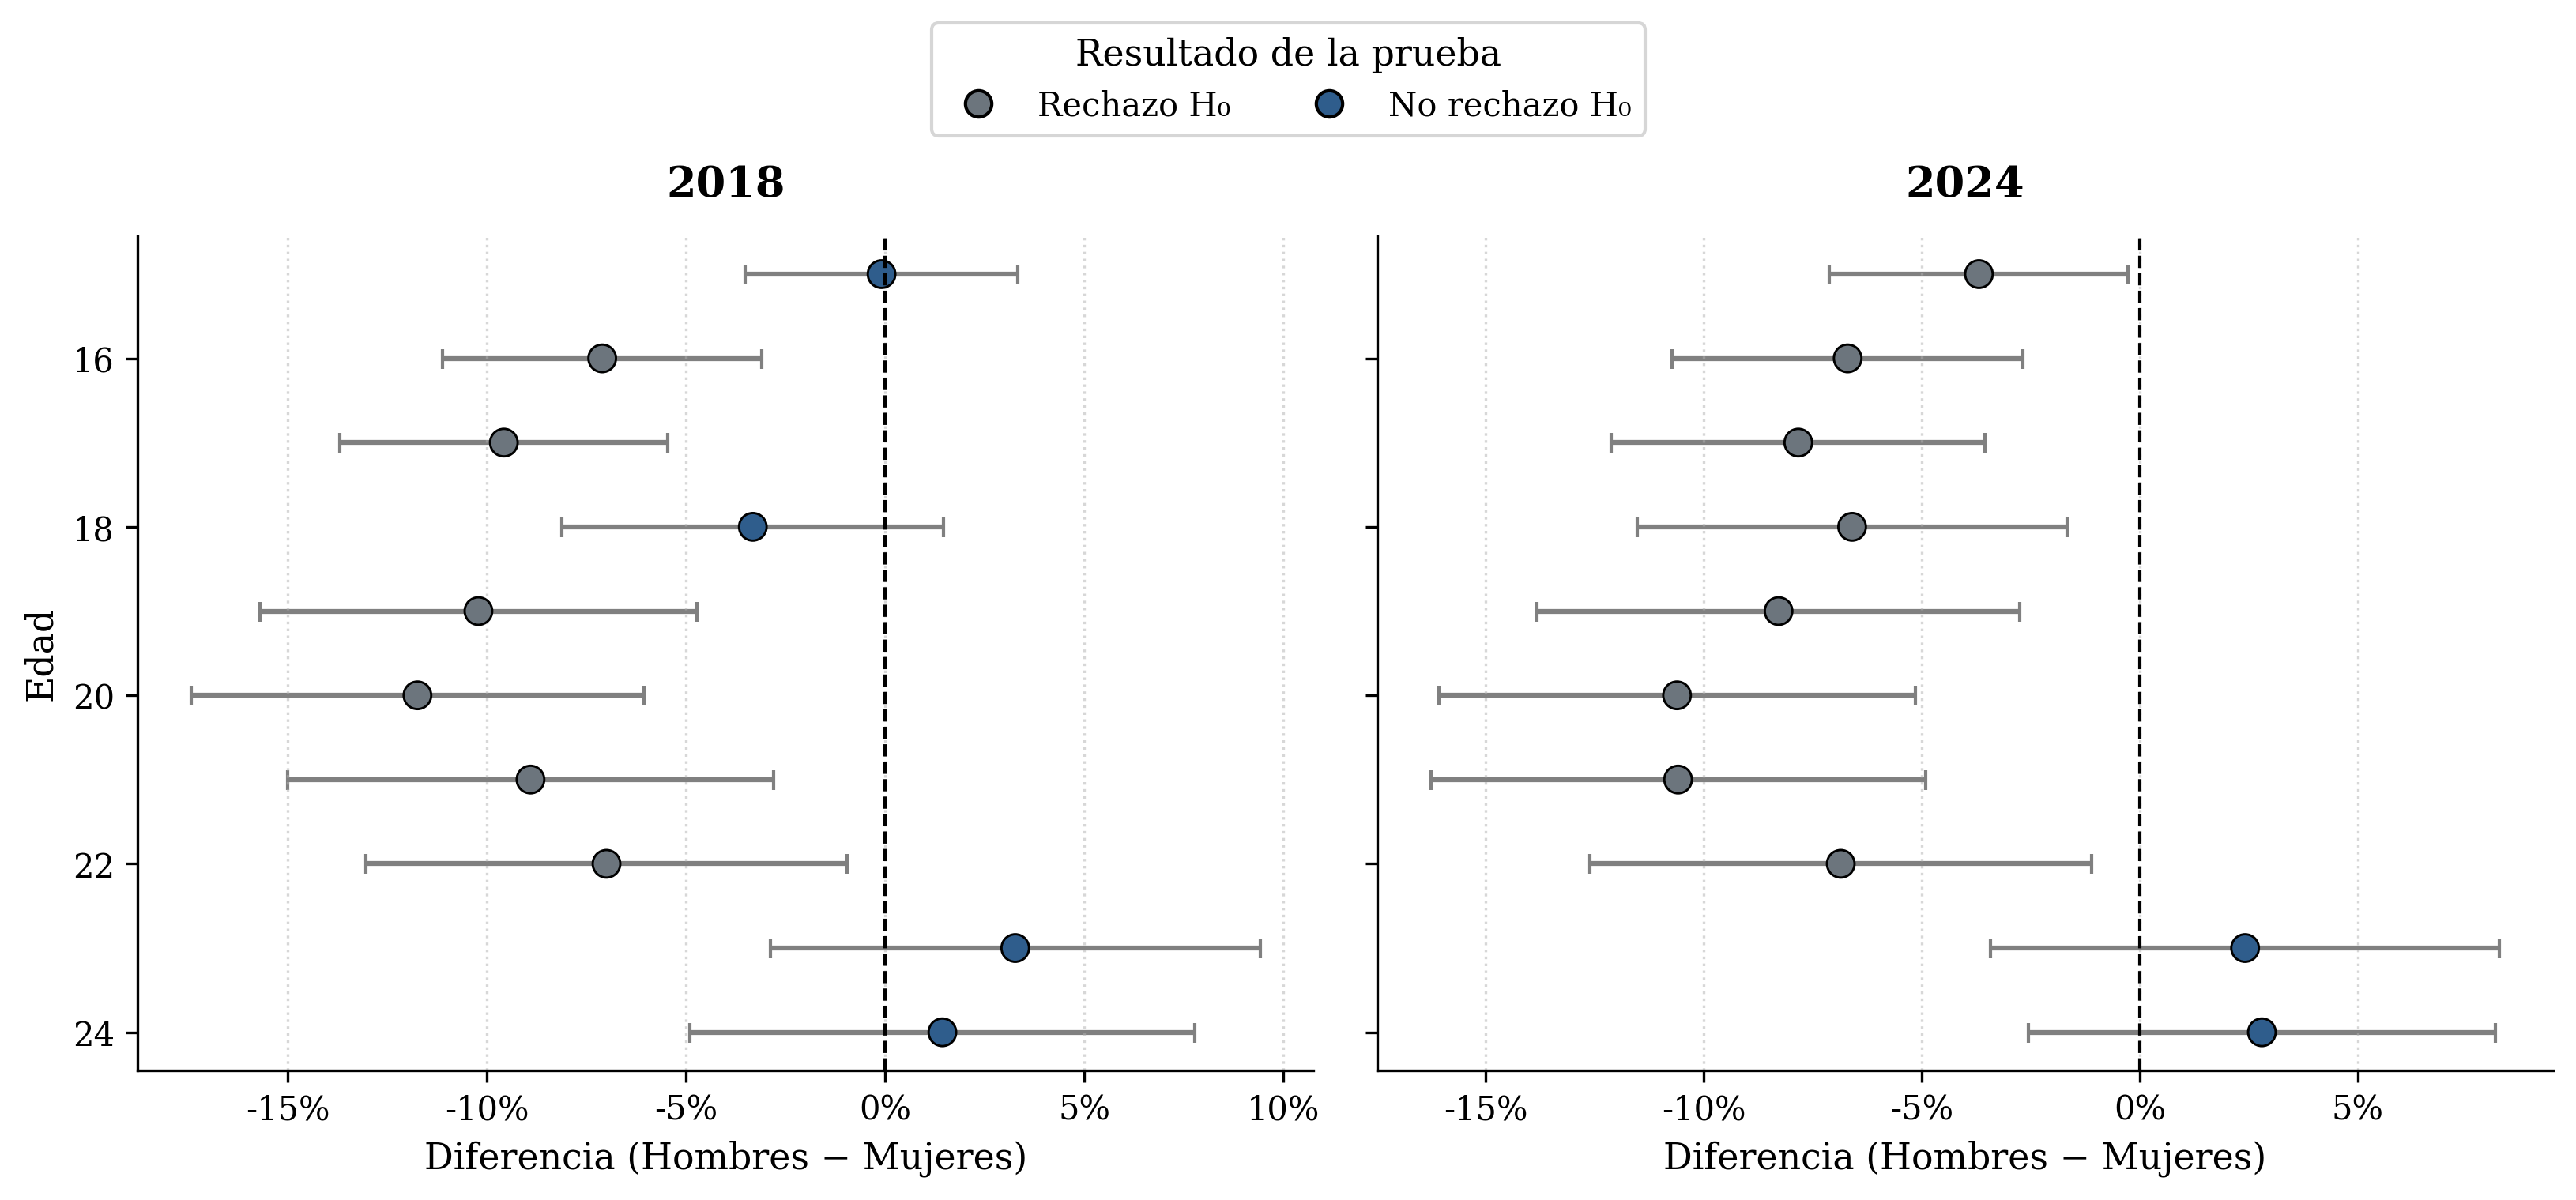

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.3'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.dpi': 300
})

# =============================================
# PREPARACIÓN DE DATOS
# =============================================
# Se asume que res_df ya existe

graf = res_df_1.copy()

graf = graf[pd.to_numeric(graf["Edad"], errors="coerce").notna()].copy()
graf["Edad"] = graf["Edad"].astype(int)
graf = graf.sort_values(["Anio", "Edad"])

# =============================================
# COLORES
# =============================================
color_map = {
    "Rechazo H0": "#6C757D",
    "No rechazo H0": "#2F5D8C"
}

years = sorted(graf["Anio"].unique())

# =============================================
# CREACIÓN DE LA FIGURA
# =============================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    sharey=True
)

for ax, year in zip(axes, years):

    df_year = graf[graf["Anio"] == year].copy()

    colors = df_year["Decisión"].map(color_map)

    lower = df_year["Diferencia (H-M)"] - df_year["IC95% inferior"]
    upper = df_year["IC95% superior"] - df_year["Diferencia (H-M)"]

    # =============================================
    # INTERVALOS DE CONFIANZA
    # =============================================
    ax.errorbar(
        df_year["Diferencia (H-M)"],
        df_year["Edad"],
        xerr=[lower, upper],
        fmt="none",
        ecolor="gray",
        elinewidth=1.5,
        capsize=3,
        zorder=1
    )

    # =============================================
    # ESTIMACIONES
    # =============================================
    ax.scatter(
        df_year["Diferencia (H-M)"],
        df_year["Edad"],
        s=70,
        c=colors,
        edgecolor="black",
        linewidth=0.7,
        zorder=2
    )

    # Línea de referencia
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # =============================================
    # TÍTULO DEL PANEL
    # =============================================
    ax.set_title(str(year), pad=12)

    # =============================================
    # EJES
    # =============================================
    ax.set_xlabel("Diferencia (Hombres − Mujeres)")

    ax.grid(
        axis='x',
        linestyle=':',
        alpha=0.5
    )

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =============================================
# EJE Y
# =============================================
axes[0].set_ylabel("Edad")
axes[0].invert_yaxis()

# =============================================
# LEYENDA GENERAL
# =============================================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#6C757D",
        markeredgecolor="black",
        markersize=8,
        label="Rechazo H₀"
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#2F5D8C",
        markeredgecolor="black",
        markersize=8,
        label="No rechazo H₀"
    )
]

fig.legend(
    handles=legend_elements,
    title="Resultado de la prueba",
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# GUARDADO
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'),
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'),
    bbox_inches='tight'
)

plt.show()

In [8]:
# ======================================
# PRUEBA DE DIFERENCIAS – APORTACIÓN JÓVENES
# ======================================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata

# === 1. Cargar datos ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Ingreso por asistencia y edad"

df = pd.read_excel(ruta, sheet_name=hoja)

# === 2. Normalizar nombres de columnas ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar para facilitar el acceso
renombres = {
    "anio": "Anio",
    "año": "Anio",
    "edad": "Edad",
    "asistencia": "Asistencia",
    "contando_aportacion_de_jovenes": "Contando_aportacion_de_jovenes",
    "media": "Media",
    "error_estandar_linealizado": "Se"
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# === 3. Limpiar formato numérico de variables de ingreso ===
df["Media"] = df["Media"].replace(r"[\$,]", "", regex=True).astype(float)
df["Se"] = df["Se"].replace(r"[\$,]", "", regex=True).astype(float)

# === 4. Calcular diferencias entre "Sí" y "No" por edad, año y asistencia ===
resultados = []

for (anio, edad, asistencia), grupo in df.groupby(["Anio", "Edad", "Asistencia"]):

    if len(grupo["Contando_aportacion_de_jovenes"].unique()) < 2:
        continue  # debe haber ambos grupos

    grupo_si = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "si"]
    grupo_no = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "no"]

    if len(grupo_si) == 0 or len(grupo_no) == 0:
        continue

    media_si = grupo_si["Media"].values[0]
    media_no = grupo_no["Media"].values[0]
    se_si = grupo_si["Se"].values[0]
    se_no = grupo_no["Se"].values[0]

    diff = media_si - media_no
    se_comb = np.sqrt(se_si**2 + se_no**2)
    z = diff / se_comb if se_comb > 0 else np.nan
    p_valor = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    ci_low = diff - 1.96 * se_comb
    ci_high = diff + 1.96 * se_comb

    resultados.append({
        "Año": anio,
        "Edad": edad,
        "Asistencia": asistencia,
        "Media (Sí)": media_si,
        "Media (No)": media_no,
        "Diferencia (Sí - No)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p_valor,
        "IC95% inferior": ci_low,
        "IC95% superior": ci_high,
        "Decisión": "Rechazo H0" if (not np.isnan(p_valor) and p_valor < 0.05) else "No rechazo H0"
    })

res_df = pd.DataFrame(resultados)

# === 5. Formato de salida bonito ===
import dataframe_image as dfi

styled = (
    res_df.style
    .format({
        "Media (Sí)": "${:,.2f}".format,
        "Media (No)": "${:,.2f}".format,
        "Diferencia (Sí - No)": "${:,.2f}".format,
        "Error Estándar": "{:.3f}".format,
        "Z": "{:.2f}".format,
        "Valor-p": "{:.4f}".format,
        "IC95% inferior": "${:,.2f}".format,
        "IC95% superior": "${:,.2f}".format
    })
    .map(
        lambda x: "background-color: lightgreen; color: black" if x == "Rechazo H0"
                  else ("background-color: salmon; color: black" if x == "No rechazo H0" else ""),
        subset=["Decisión"]
    )
    .background_gradient(subset=["Valor-p"], cmap="RdYlGn_r")
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-size", "11pt"),
                                     ("background-color", "#f2f2f2"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)




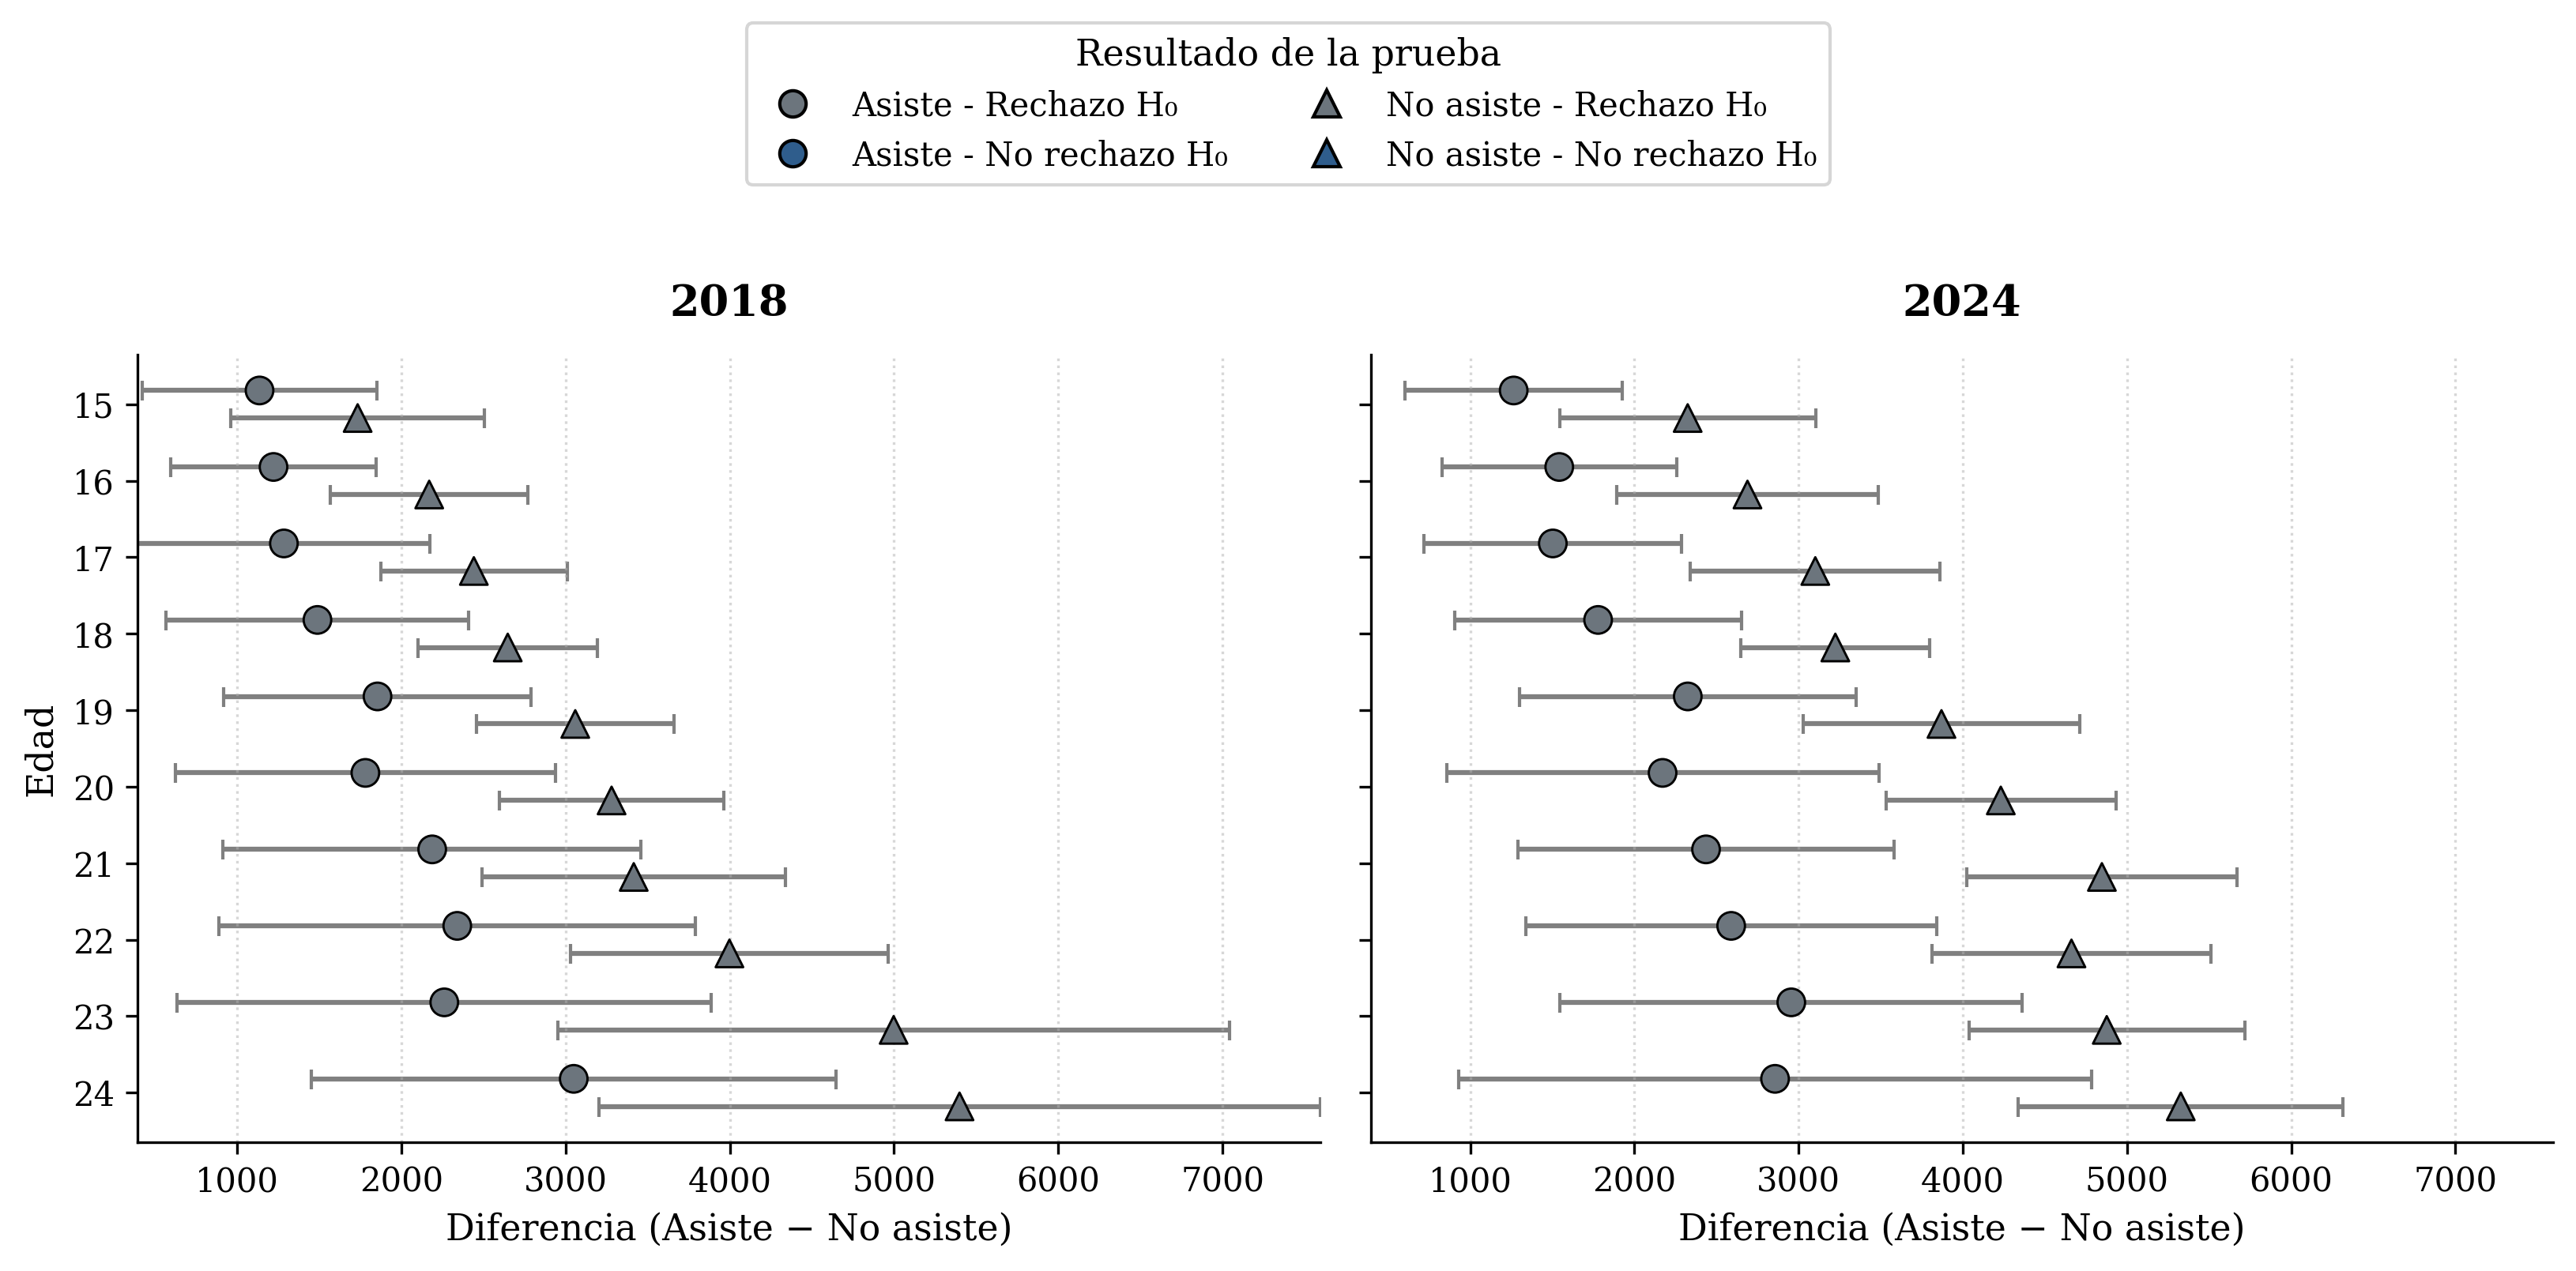

In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.4'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.dpi': 300
})

# =============================================
# PREPARACIÓN DE DATOS
# =============================================
graf = res_df.copy()

graf = graf[pd.to_numeric(graf["Edad"], errors="coerce").notna()].copy()
graf["Edad"] = graf["Edad"].astype(int)
graf["Año"] = graf["Año"].astype(str)

graf = graf.sort_values(["Año", "Edad", "Asistencia"])

years = sorted(graf["Año"].unique())

# =============================================
# CONFIGURACIÓN DE CATEGORÍAS
# =============================================
offset = {
    "Asiste": -0.18,
    "Sí": -0.18,
    "Si": -0.18,
    "No asiste": 0.18,
    "No": 0.18
}

markers = {
    "Asiste": "o",
    "Sí": "o",
    "Si": "o",
    "No asiste": "^",
    "No": "^"
}

color_map = {
    "Rechazo H0": "#6C757D",
    "No rechazo H0": "#2F5D8C"
}

# =============================================
# CREACIÓN DE LA FIGURA
# =============================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    sharex=True,
    sharey=True
)

for ax, year in zip(axes, years):

    datos = graf[graf["Año"] == year]

    for asistencia in datos["Asistencia"].unique():

        d = datos[datos["Asistencia"] == asistencia].copy()

        y = d["Edad"] + offset.get(asistencia, 0)

        colores = d["Decisión"].map(color_map)

        lower = d["Diferencia (Sí - No)"] - d["IC95% inferior"]
        upper = d["IC95% superior"] - d["Diferencia (Sí - No)"]

        # =============================================
        # INTERVALOS DE CONFIANZA
        # =============================================
        ax.errorbar(
            d["Diferencia (Sí - No)"],
            y,
            xerr=[lower, upper],
            fmt="none",
            ecolor="gray",
            capsize=3,
            elinewidth=1.5,
            zorder=1
        )

        # =============================================
        # PUNTOS ESTIMADOS
        # =============================================
        ax.scatter(
            d["Diferencia (Sí - No)"],
            y,
            s=70,
            marker=markers.get(asistencia, "o"),
            c=colores,
            edgecolor="black",
            linewidth=0.7,
            zorder=2
        )

    # Línea de referencia
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    # =============================================
    # TÍTULO DEL PANEL
    # =============================================
    ax.set_title(str(year), pad=12)

    # =============================================
    # EJES
    # =============================================
    ax.set_xlabel("Diferencia (Asiste − No asiste)")

    ax.grid(
        axis='x',
        linestyle=':',
        alpha=0.5
    )



    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =============================================
# MISMA ESCALA HORIZONTAL EN AMBOS PANELES
# =============================================
xmin = graf["IC95% inferior"].min() - 0.02
xmax = graf["IC95% superior"].max() + 0.02

for ax in axes:
    ax.set_xlim(xmin, xmax)

# =============================================
# EJE Y
# =============================================
axes[0].set_ylabel("Edad")
axes[0].set_yticks(sorted(graf["Edad"].unique()))
axes[0].invert_yaxis()

# =============================================
# LEYENDA GENERAL
# =============================================
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#6C757D",
        markeredgecolor='black',
        markersize=8,
        label='Asiste - Rechazo H₀'
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#2F5D8C",
        markeredgecolor='black',
        markersize=8,
        label='Asiste - No rechazo H₀'
    ),

    Line2D(
        [0], [0],
        marker='^',
        color='w',
        markerfacecolor="#6C757D",
        markeredgecolor='black',
        markersize=8,
        label='No asiste - Rechazo H₀'
    ),

    Line2D(
        [0], [0],
        marker='^',
        color='w',
        markerfacecolor="#2F5D8C",
        markeredgecolor='black',
        markersize=8,
        label='No asiste - No rechazo H₀'
    )

]

fig.legend(
    handles=legend_elements,
    title="Resultado de la prueba",
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.88])

# =============================================
# GUARDADO
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'),
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'),
    bbox_inches='tight'
)

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/2707239040.py:117: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


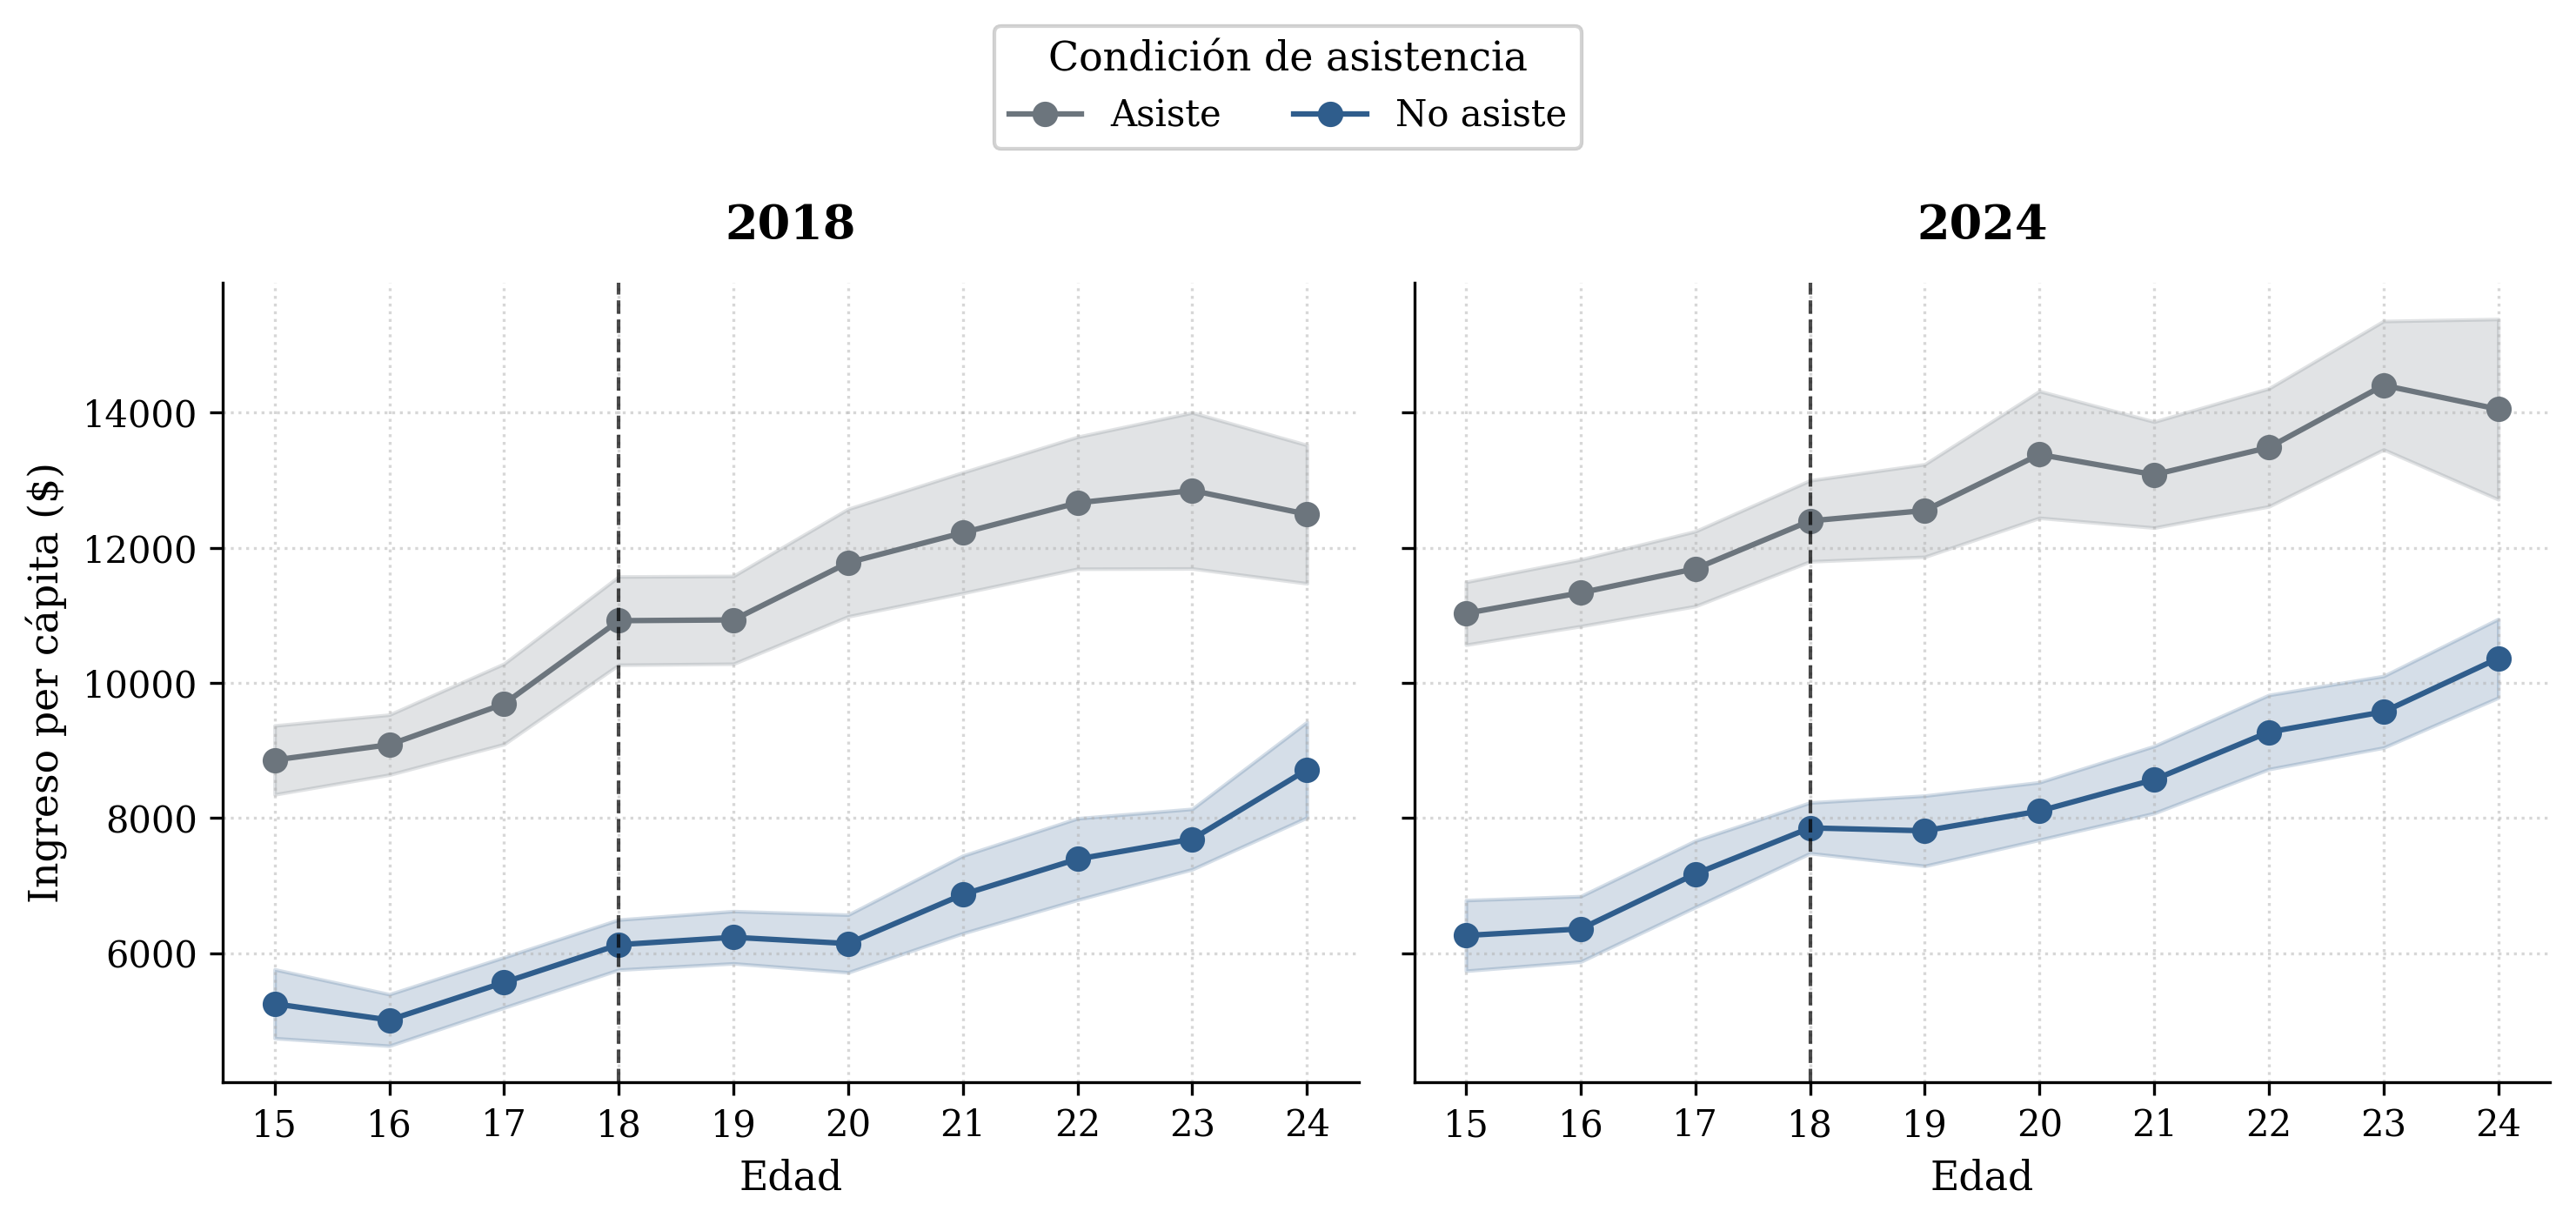

In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.5'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
df = pd.read_excel(ruta, sheet_name="Ingreso por asistencia y edad")

# Filtrar solo “No” en la columna de aportación
df = df[df["Contando aportacion de jovenes"] == "No"]

# Limpieza de columnas numéricas
cols_numericas = [
    "Media",
    "Error Estandar Linealizado",
    "Intervalo de confianza inferior",
    "Intervalo de confianza superior"
]
for c in cols_numericas:
    df[c] = df[c].replace(r"[\$,]", "", regex=True).astype(float)

# =============================================
# FUNCIÓN PARA GRAFICAR EN UN EJE
# =============================================
def plot_por_anio(df, anio, ax):
    df_anio = df[df["Anio"] == anio]

    # Colores fijos según el orden: Asiste -> #6C757D, No asiste -> #2F5D8C
    colores = {
        "Asiste": "#6C757D",
        "No asiste": "#2F5D8C"
    }

    for grupo, color in colores.items():
        df_g = df_anio[df_anio["Asistencia"] == grupo]

        # Línea principal
        ax.plot(
            df_g["Edad"],
            df_g["Media"],
            label=grupo,
            color=color,
            marker="o",
            linewidth=1.5
        )

        # Banda de confianza
        ax.fill_between(
            df_g["Edad"],
            df_g["Intervalo de confianza inferior"],
            df_g["Intervalo de confianza superior"],
            color=color,
            alpha=0.2
        )

    # Línea vertical en edad 18 (referencia)
    ax.axvline(x=18, color="black", linestyle="--", linewidth=1, alpha=0.7)

        # Título del panel
    ax.set_title(str(anio), fontsize=13, fontweight='bold', pad=12)

    # Forzar marcas en el eje X de 1 en 1
    min_edad = df_anio['Edad'].min()
    max_edad = df_anio['Edad'].max()
    marcas_x = np.arange(min_edad, max_edad + 1)
    ax.set_xticks(marcas_x)

    # Etiquetas de ejes
    ax.set_xlabel("Edad")
    if ax == axes[0]:  # solo el primer subplot lleva la etiqueta del eje Y
        ax.set_ylabel("Ingreso per cápita ($)")

    # Rejilla en ambos ejes (valores) con estilo unificado
    ax.grid(axis='both', linestyle=':', alpha=0.5)

    # Eliminar spines superiores y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # =============================================
    # LEYENDA GENERAL (ARRIBA)
    # =============================================
    handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title='Condición de asistencia',
        ncol=2,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.05),
        frameon=True
    )

    # Dejar espacio para la leyenda
    fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# CREACIÓN DE SUBPLOTS (1 fila, 2 columnas)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True, sharey=True)

plot_por_anio(df, 2018, axes[0])
plot_por_anio(df, 2024, axes[1])

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/3346573277.py:136: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


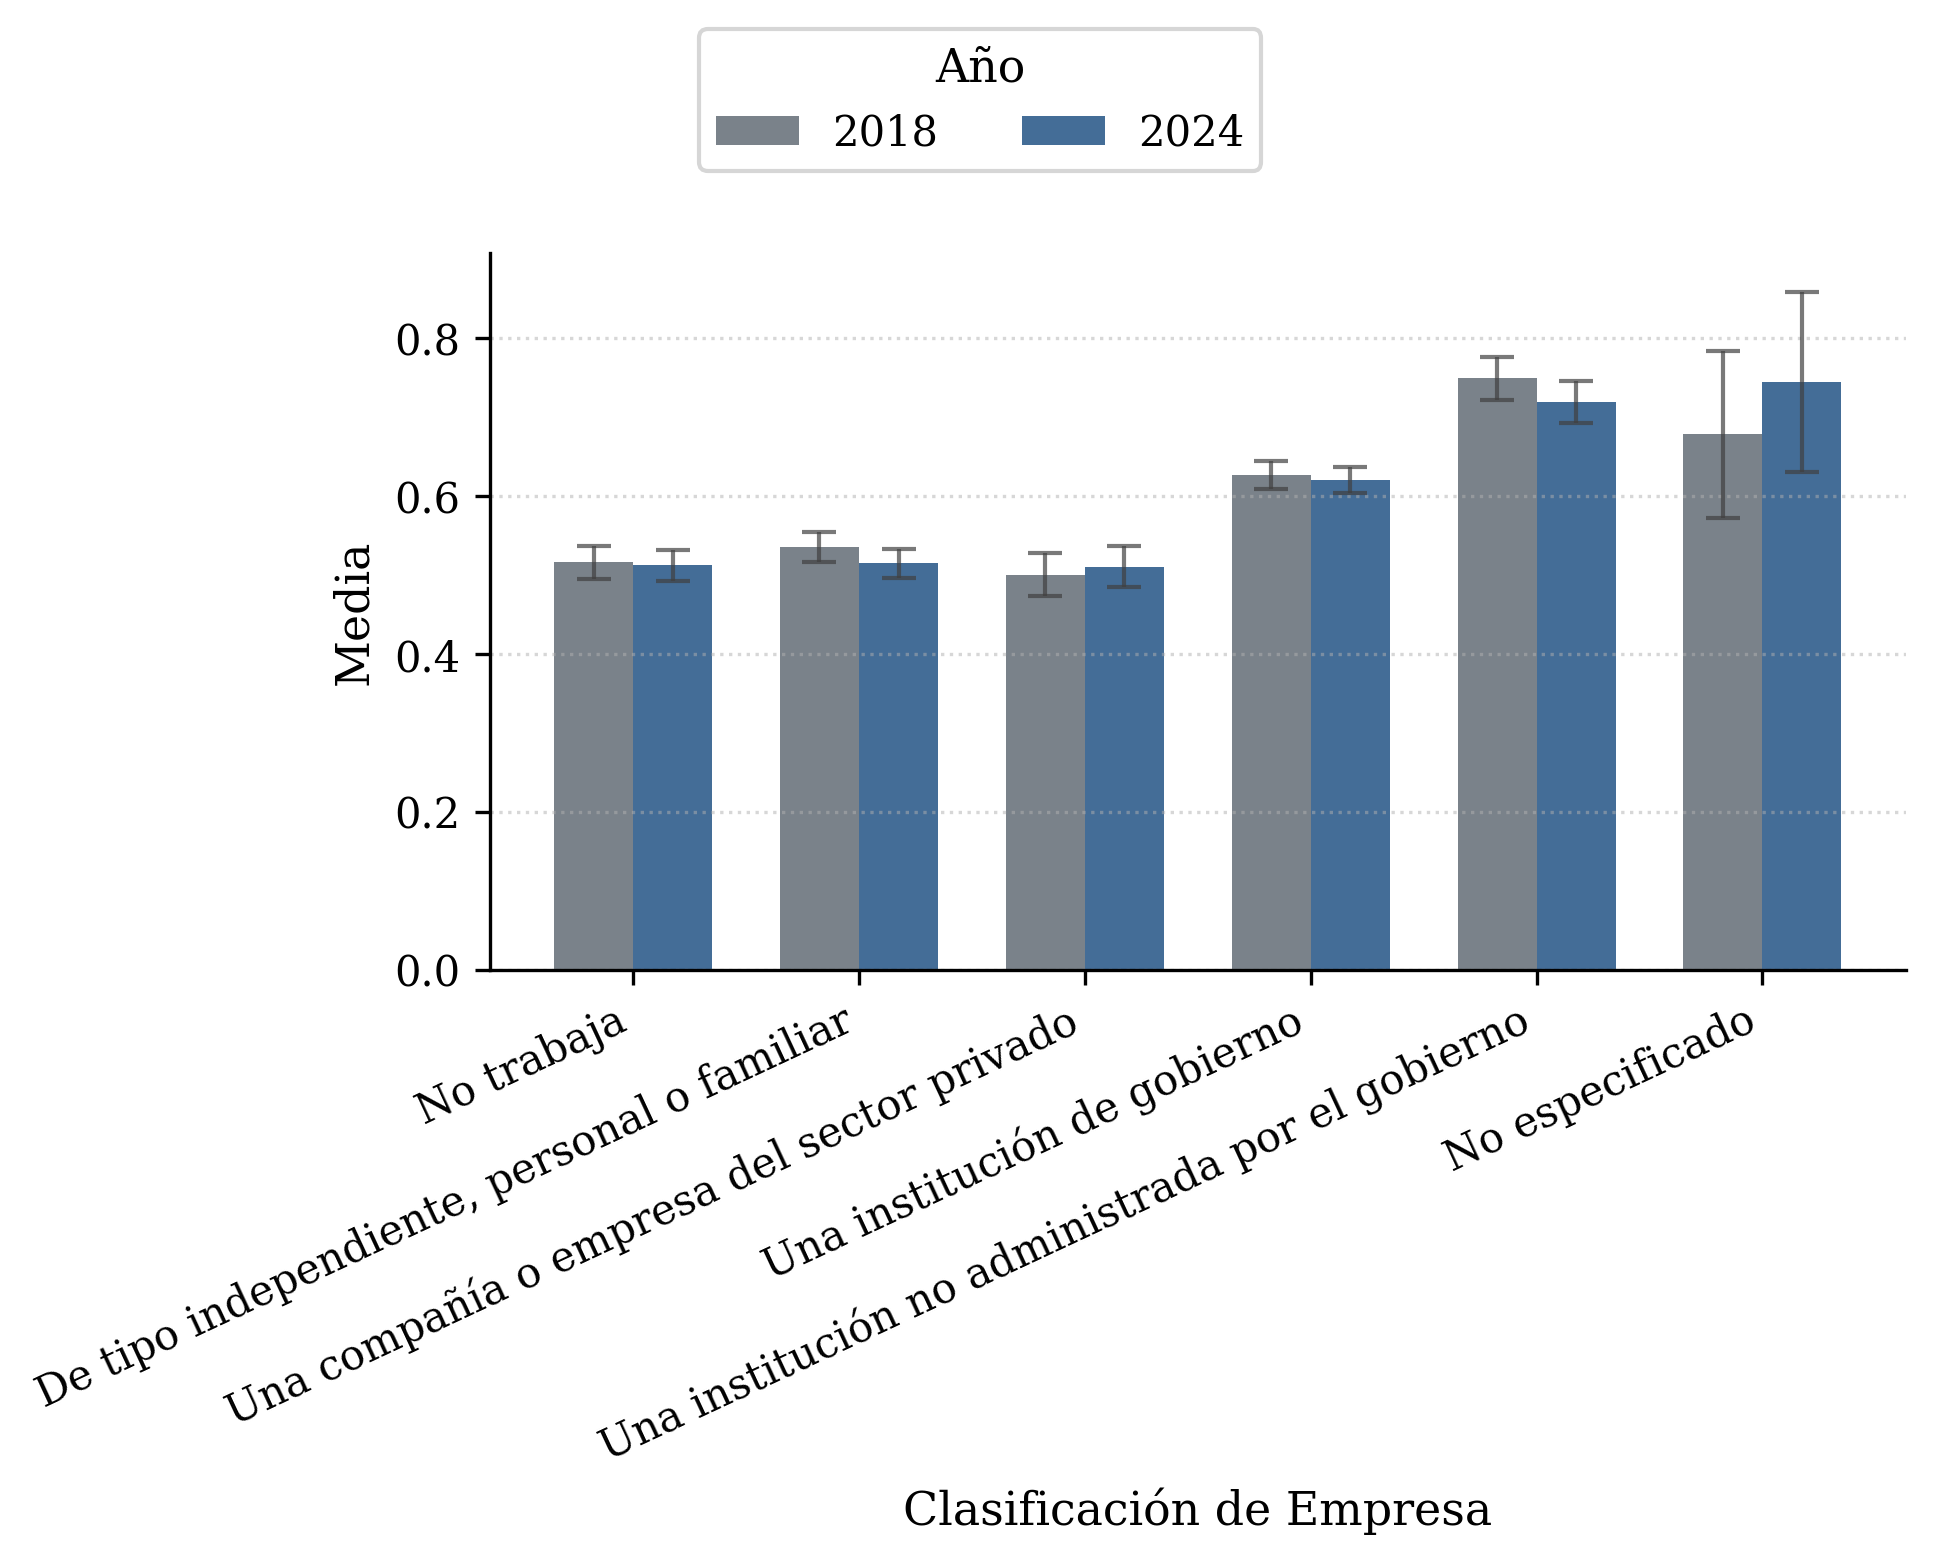

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.6'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "Trabajos"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

df.rename(columns={
    "anio": "Anio",
    "clasificacion_empresa": "Clasificacion_empresa",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# Calcular errores asimétricos
df['yerr_inf'] = df['Media'] - df['IC_inf']
df['yerr_sup'] = df['IC_sup'] - df['Media']

# Preparar posiciones y categorías
categorias = df['Clasificacion_empresa'].unique()
x_base = np.arange(len(categorias))
bar_width = 0.35

df_2018 = df[df['Anio'] == '2018'].sort_values('Clasificacion_empresa')
df_2024 = df[df['Anio'] == '2024'].sort_values('Clasificacion_empresa')

yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])

# =============================================
# CREACIÓN DE LA FIGURA (una sola gráfica)
# =============================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Paleta de dos colores: 2018 -> #6C757D, 2024 -> #2F5D8C
color_2018 = '#6C757D'
color_2024 = '#2F5D8C'

# Barras para 2018
rects1 = ax.bar(
    x_base - bar_width/2,
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018,
    capsize=4,
    color=color_2018,
    alpha=0.9,
    error_kw={'ecolor': '#404040', 'linewidth': 1.0, 'alpha': 0.7}
)

# Barras para 2024
rects2 = ax.bar(
    x_base + bar_width/2,
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024,
    capsize=4,
    color=color_2024,
    alpha=0.9,
    error_kw={'ecolor': '#404040', 'linewidth': 1.0, 'alpha': 0.7}
)

# =============================================
# CONFIGURACIÓN DE EJES Y REJILLA
# =============================================
ax.set_ylabel('Media')
ax.set_xlabel('Clasificación de Empresa')

ax.set_xticks(x_base)
ax.set_xticklabels(categorias, rotation=25, ha='right', fontsize=10)

# Rejilla en eje Y (valores) con estilo unificado
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Eliminar spines superiores y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajuste de límites del eje Y
y_min = min(df['IC_inf'].min() - 0.05, 0)
y_max = df['IC_sup'].max() + 0.05
ax.set_ylim(y_min, y_max)

# =============================================
# LEYENDA GENERAL (ARRIBA)
# =============================================
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Año',
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/1887618015.py:135: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


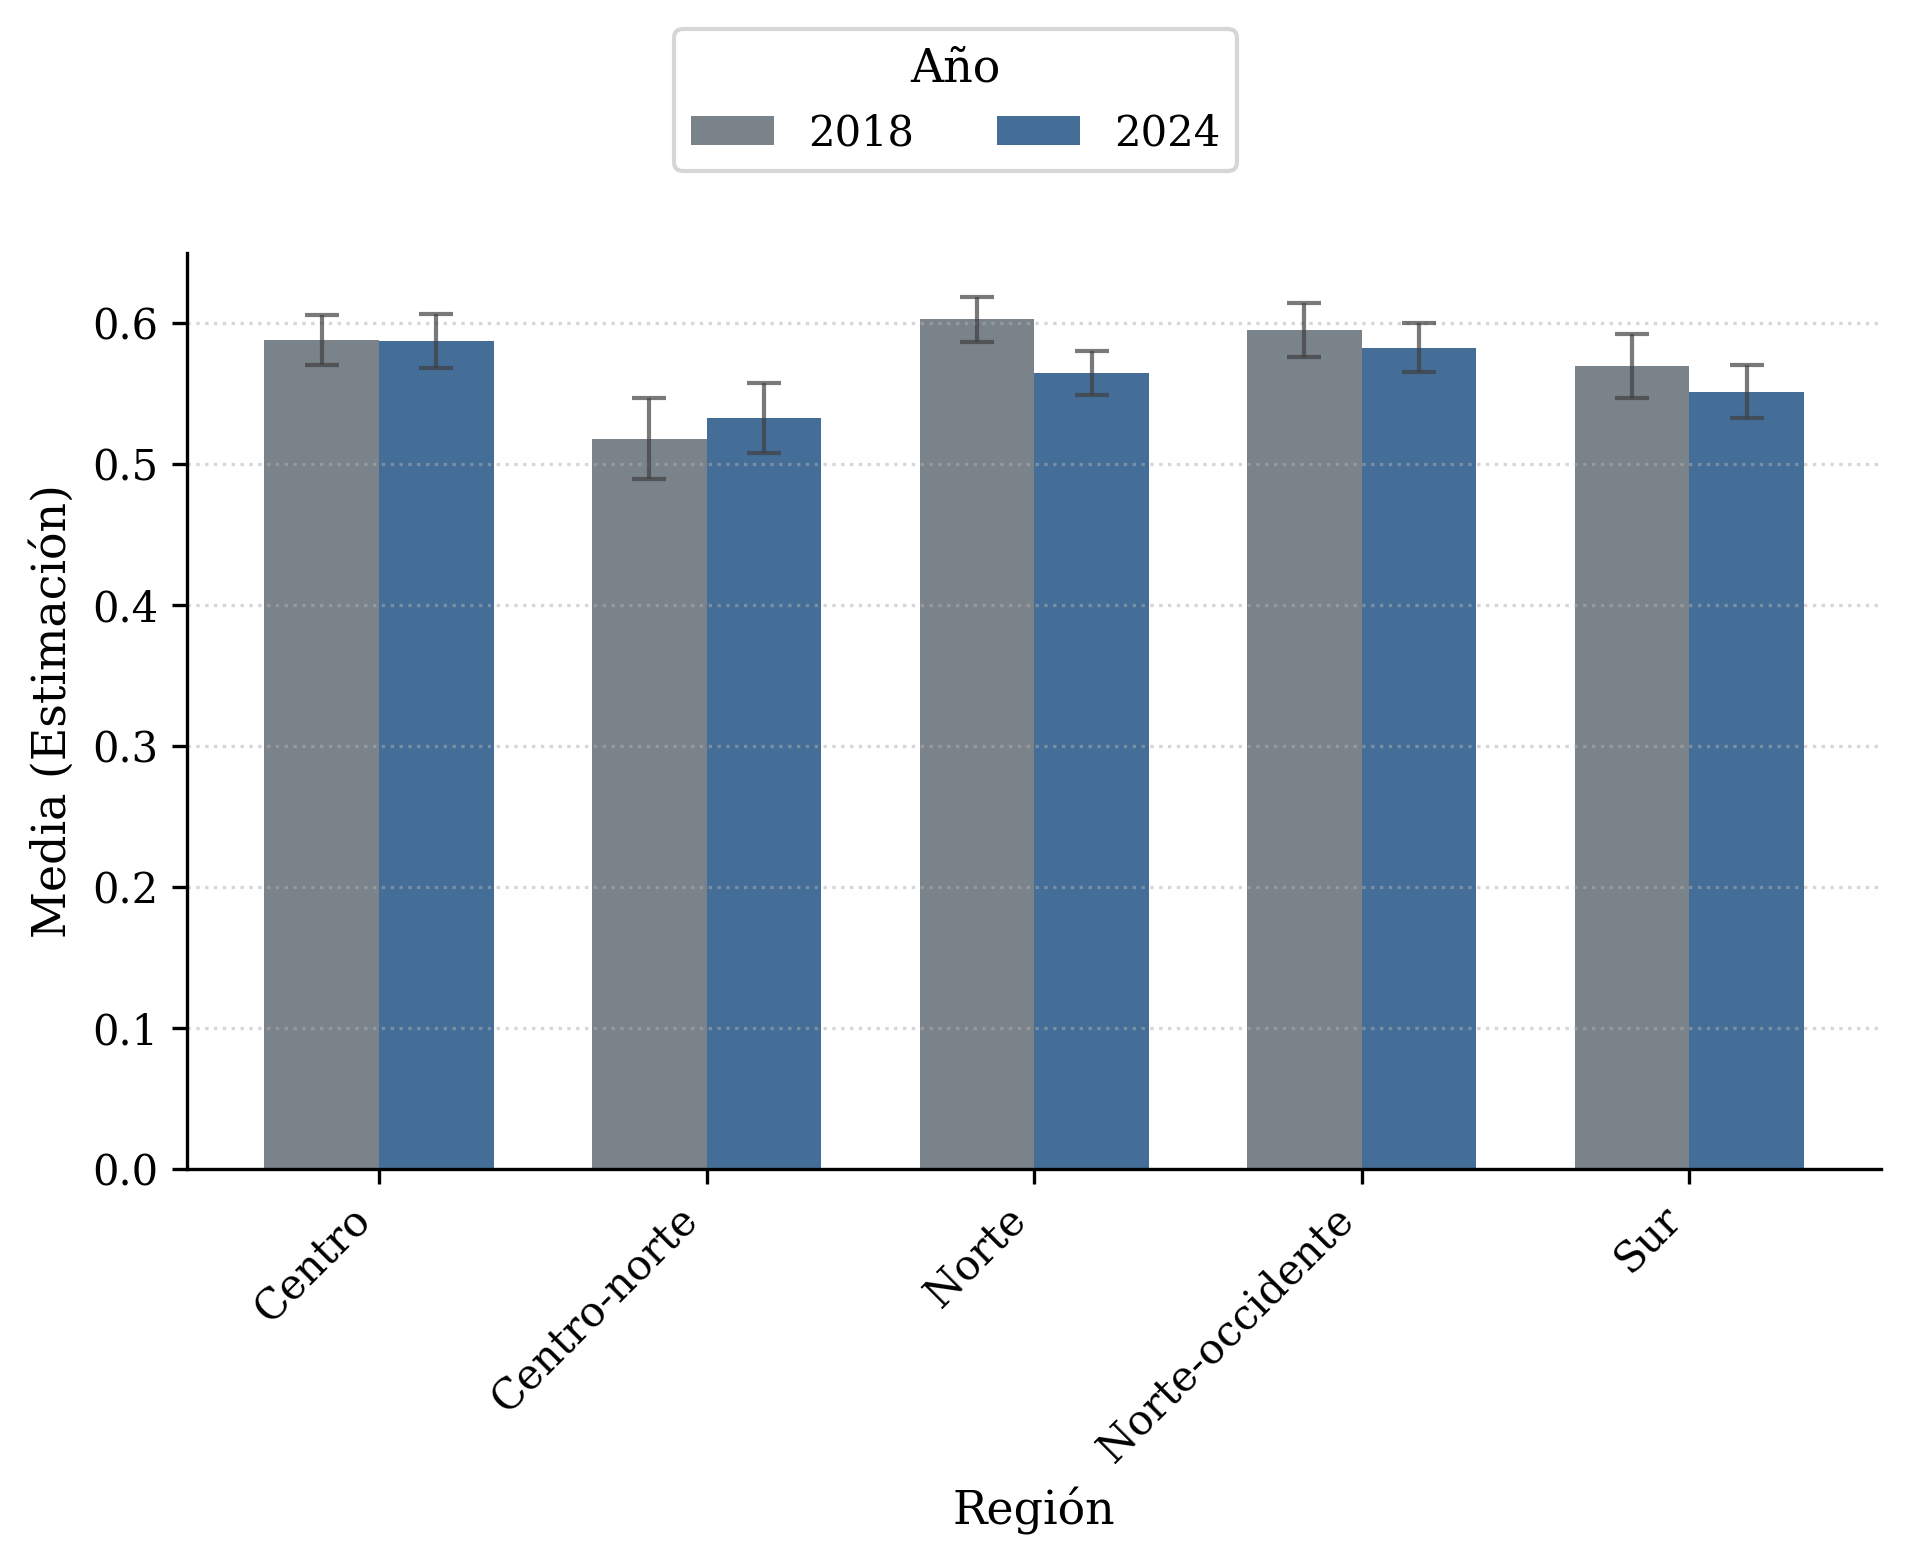

In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.7'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "Region"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

df.rename(columns={
    "anio": "Anio",
    "region": "Region",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# Calcular errores asimétricos
df['yerr_inf'] = df['Media'] - df['IC_inf']
df['yerr_sup'] = df['IC_sup'] - df['Media']

# Preparar datos
regions = df['Region'].unique()
x_base = np.arange(len(regions))
bar_width = 0.35

df_2018 = df[df['Anio'] == '2018'].sort_values('Region')
df_2024 = df[df['Anio'] == '2024'].sort_values('Region')

yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])

# =============================================
# CREACIÓN DE LA FIGURA (una sola gráfica)
# =============================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Colores fijos
color_2018 = '#6C757D'
color_2024 = '#2F5D8C'

# Barras 2018
rects1 = ax.bar(
    x_base - bar_width/2,
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018,
    capsize=4,
    color=color_2018,
    alpha=0.9,
    error_kw={'ecolor': '#404040', 'linewidth': 1.0, 'alpha': 0.7}
)

# Barras 2024
rects2 = ax.bar(
    x_base + bar_width/2,
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024,
    capsize=4,
    color=color_2024,
    alpha=0.9,
    error_kw={'ecolor': '#404040', 'linewidth': 1.0, 'alpha': 0.7}
)

# =============================================
# CONFIGURACIÓN DE EJES Y REJILLA
# =============================================
ax.set_ylabel('Media (Estimación)')
ax.set_xlabel('Región')

ax.set_xticks(x_base)
ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=10)

# Rejilla en eje Y
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Eliminar spines superiores y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Límites automáticos (se ajustan a los datos)
# Si se desea un rango fijo, se puede descomentar:
# ax.set_ylim(0.45, 0.60)

# =============================================
# LEYENDA GENERAL (ARRIBA)
# =============================================
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Año',
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/2358910456.py:122: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


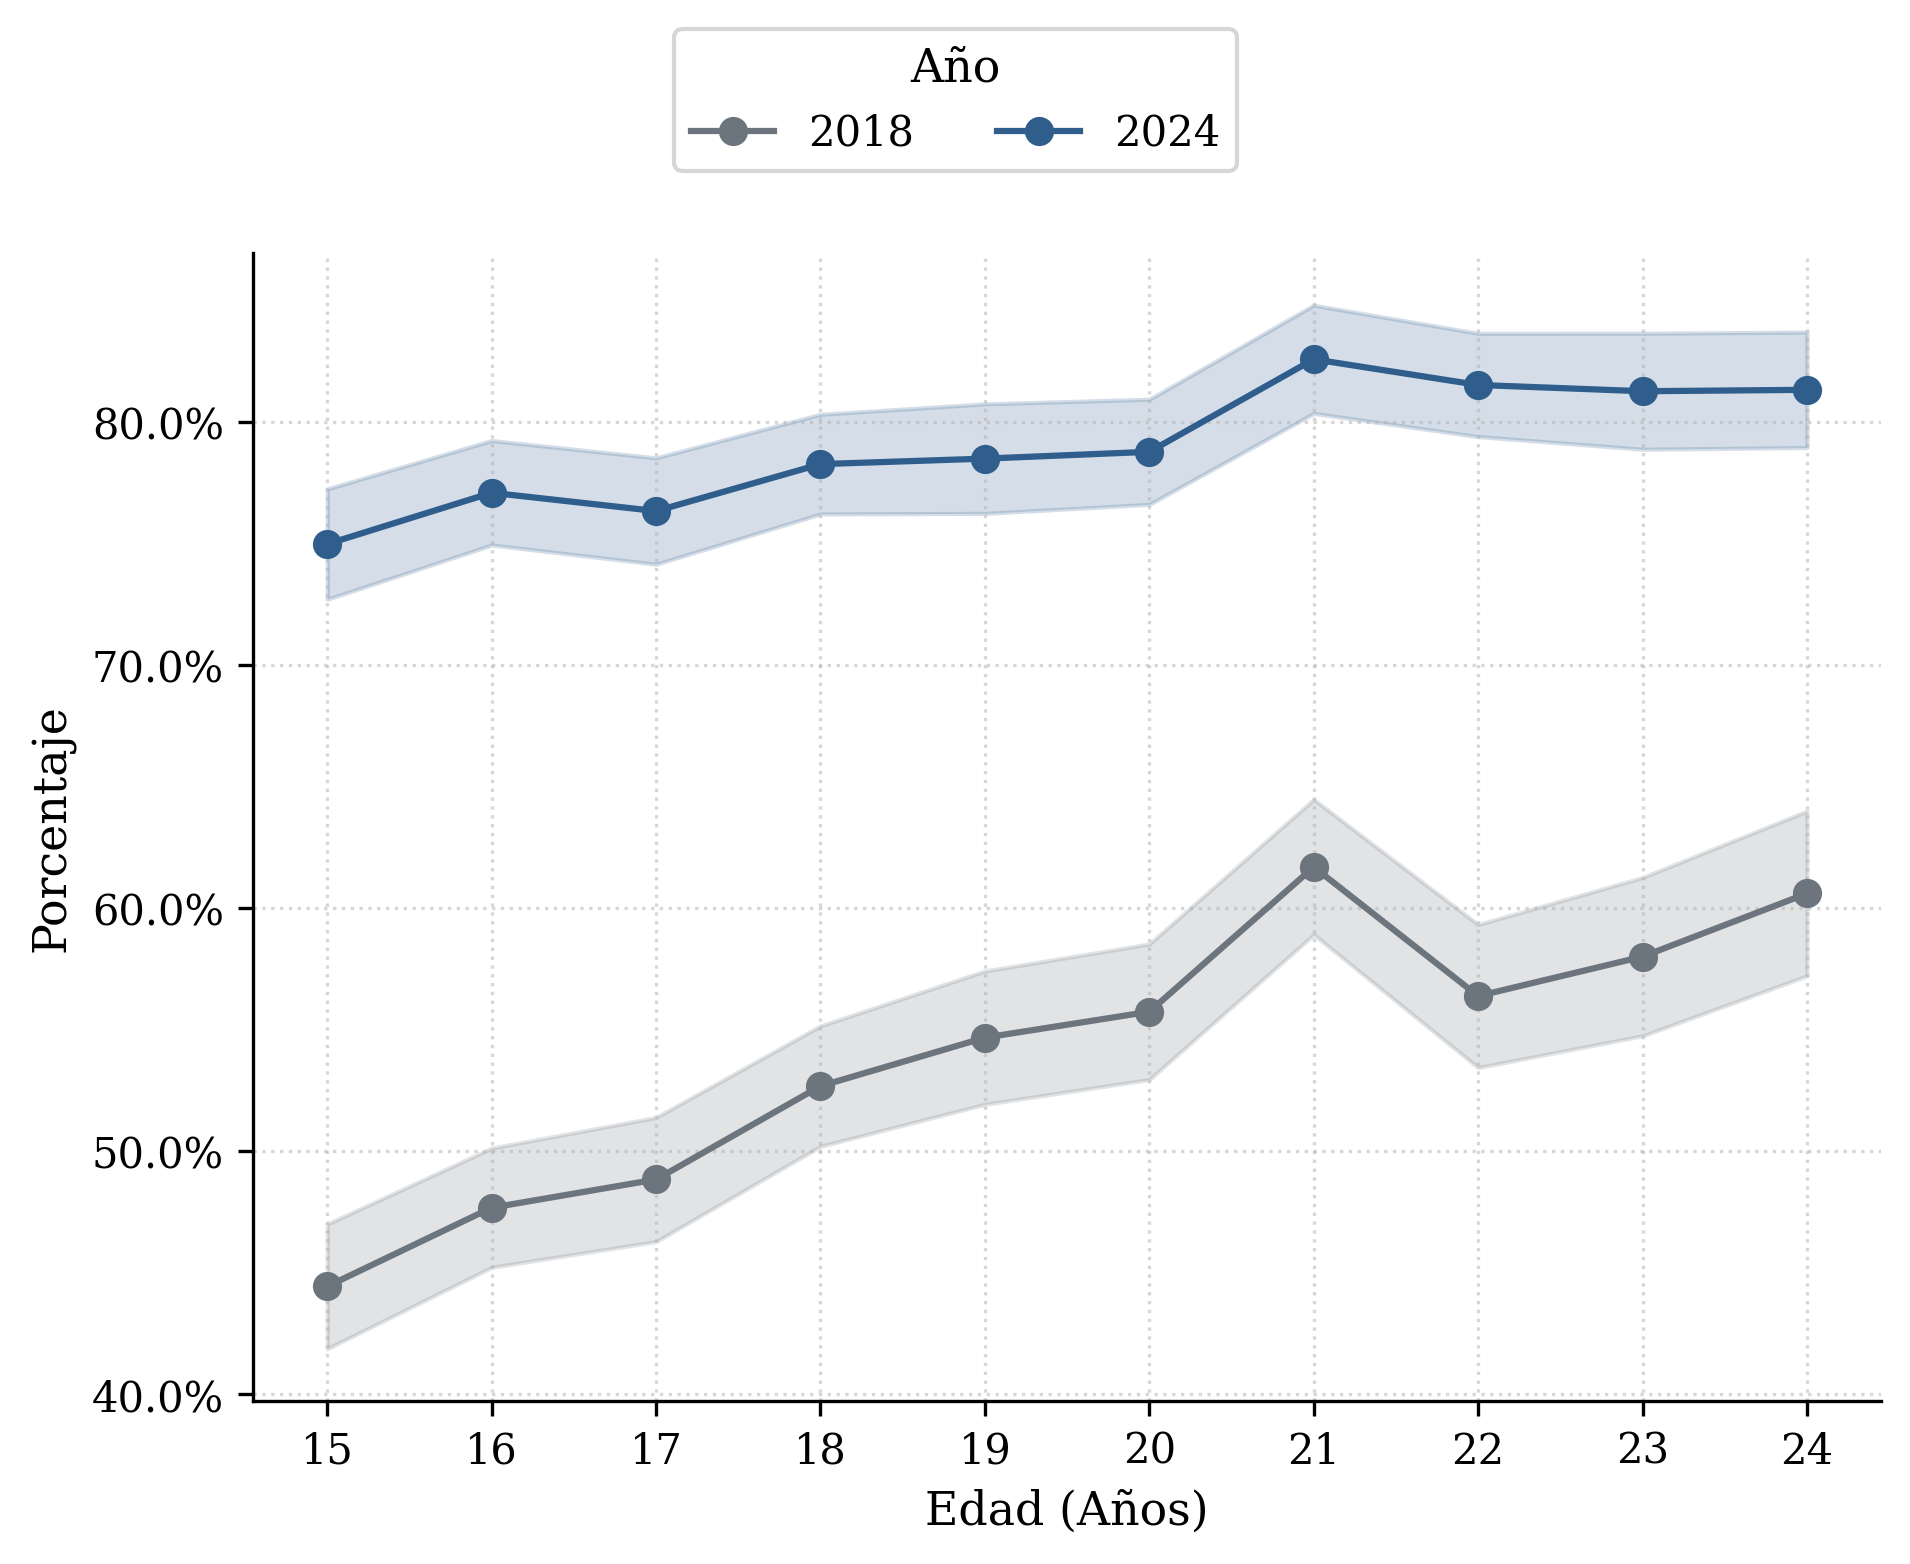

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.8'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "Internet"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# =============================================
# CREACIÓN DE LA FIGURA (una sola gráfica)
# =============================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Colores fijos según años (orden cronológico)
colores = {
    '2018': '#6C757D',
    '2024': '#2F5D8C'
}

# Dibujar bandas de confianza y líneas de media
for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%) - sin etiqueta para evitar duplicados en leyenda
    ax.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label="_nolegend_"
    )
    
    # Línea principal (media)
    ax.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=anio,           # Solo el año como etiqueta
        color=color,
        marker="o",
        linewidth=1.5
    )

# =============================================
# CONFIGURACIÓN DE EJES Y REJILLA
# =============================================
ax.set_xlabel('Edad (Años)')
ax.set_ylabel('Porcentaje')

# Forzar marcas del eje X de 1 en 1
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
ax.set_xticks(np.arange(min_edad, max_edad + 1))

# Formato porcentual en el eje Y
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Rejilla en ambos ejes con estilo unificado
ax.grid(axis='both', linestyle=':', alpha=0.5)

# Eliminar spines superiores y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =============================================
# LEYENDA GENERAL (ARRIBA)
# =============================================
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Año',
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Ajuste de límites del eje Y (opcional, según los datos se puede dejar automático)
# ax.set_ylim(0.3, 0.9)

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/2030614731.py:122: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


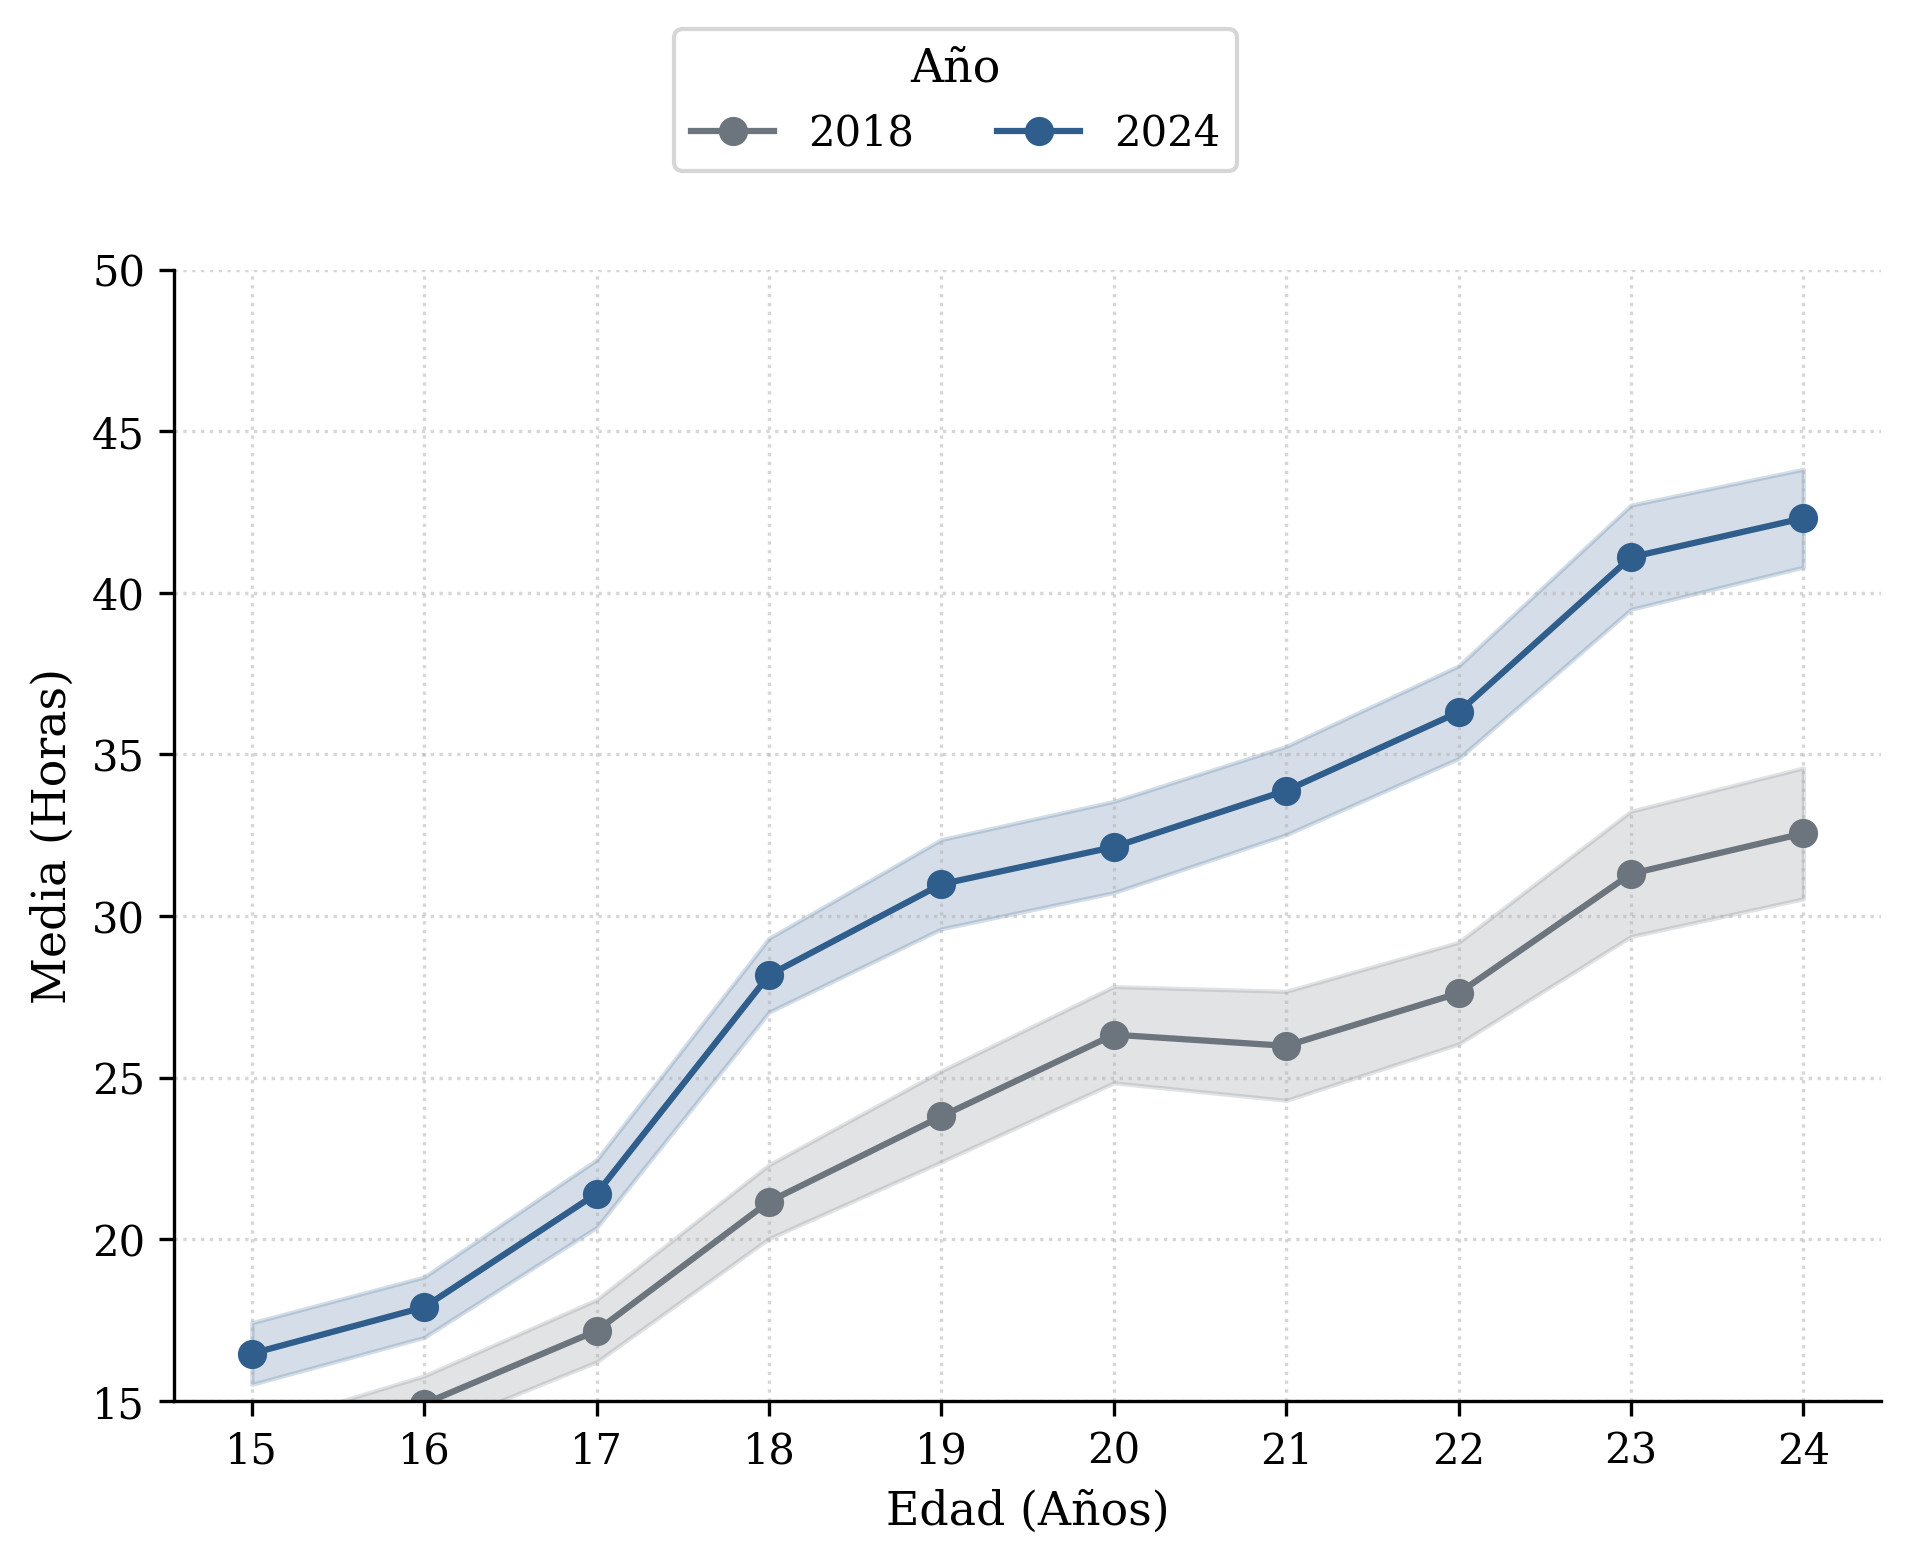

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np

# =============================================
# NÚMERO DE FIGURA
# =============================================
FIG_NUM = '3.9'

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y LIMPIEZA DE DATOS
# =============================================
ruta = "data/processed/Estadistica descriptiva.xlsx"
hoja = "Horas"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)
df['Edad'] = pd.to_numeric(df['Edad'])

# =============================================
# CREACIÓN DE LA FIGURA (una sola gráfica)
# =============================================
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

# Colores fijos según años
colores = {
    '2018': '#6C757D',
    '2024': '#2F5D8C'
}

# Dibujar bandas de confianza y líneas de media
for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%) - sin etiqueta para evitar duplicados
    ax.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label="_nolegend_"
    )
    
    # Línea principal (media)
    ax.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=anio,
        color=color,
        marker="o",
        linewidth=1.5
    )

# =============================================
# CONFIGURACIÓN DE EJES Y REJILLA
# =============================================
ax.set_xlabel('Edad (Años)')
ax.set_ylabel('Media (Horas)')

# Forzar marcas del eje X de 1 en 1
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
ax.set_xticks(np.arange(min_edad, max_edad + 1))

# Rejilla en ambos ejes
ax.grid(axis='both', linestyle=':', alpha=0.5)

# Eliminar spines superiores y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Límites del eje Y (según datos originales)
ax.set_ylim(15, 50)

# =============================================
# LEYENDA GENERAL (ARRIBA)
# =============================================
handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Año',
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    frameon=True
)

# Dejar espacio para la leyenda
fig.tight_layout(rect=[0, 0, 1, 0.92])

# =============================================
# GUARDADO EN OUTPUTS/FIGURES
# =============================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, f'Figura_{FIG_NUM}.svg'), bbox_inches='tight')

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/2340052498.py:135: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.88])


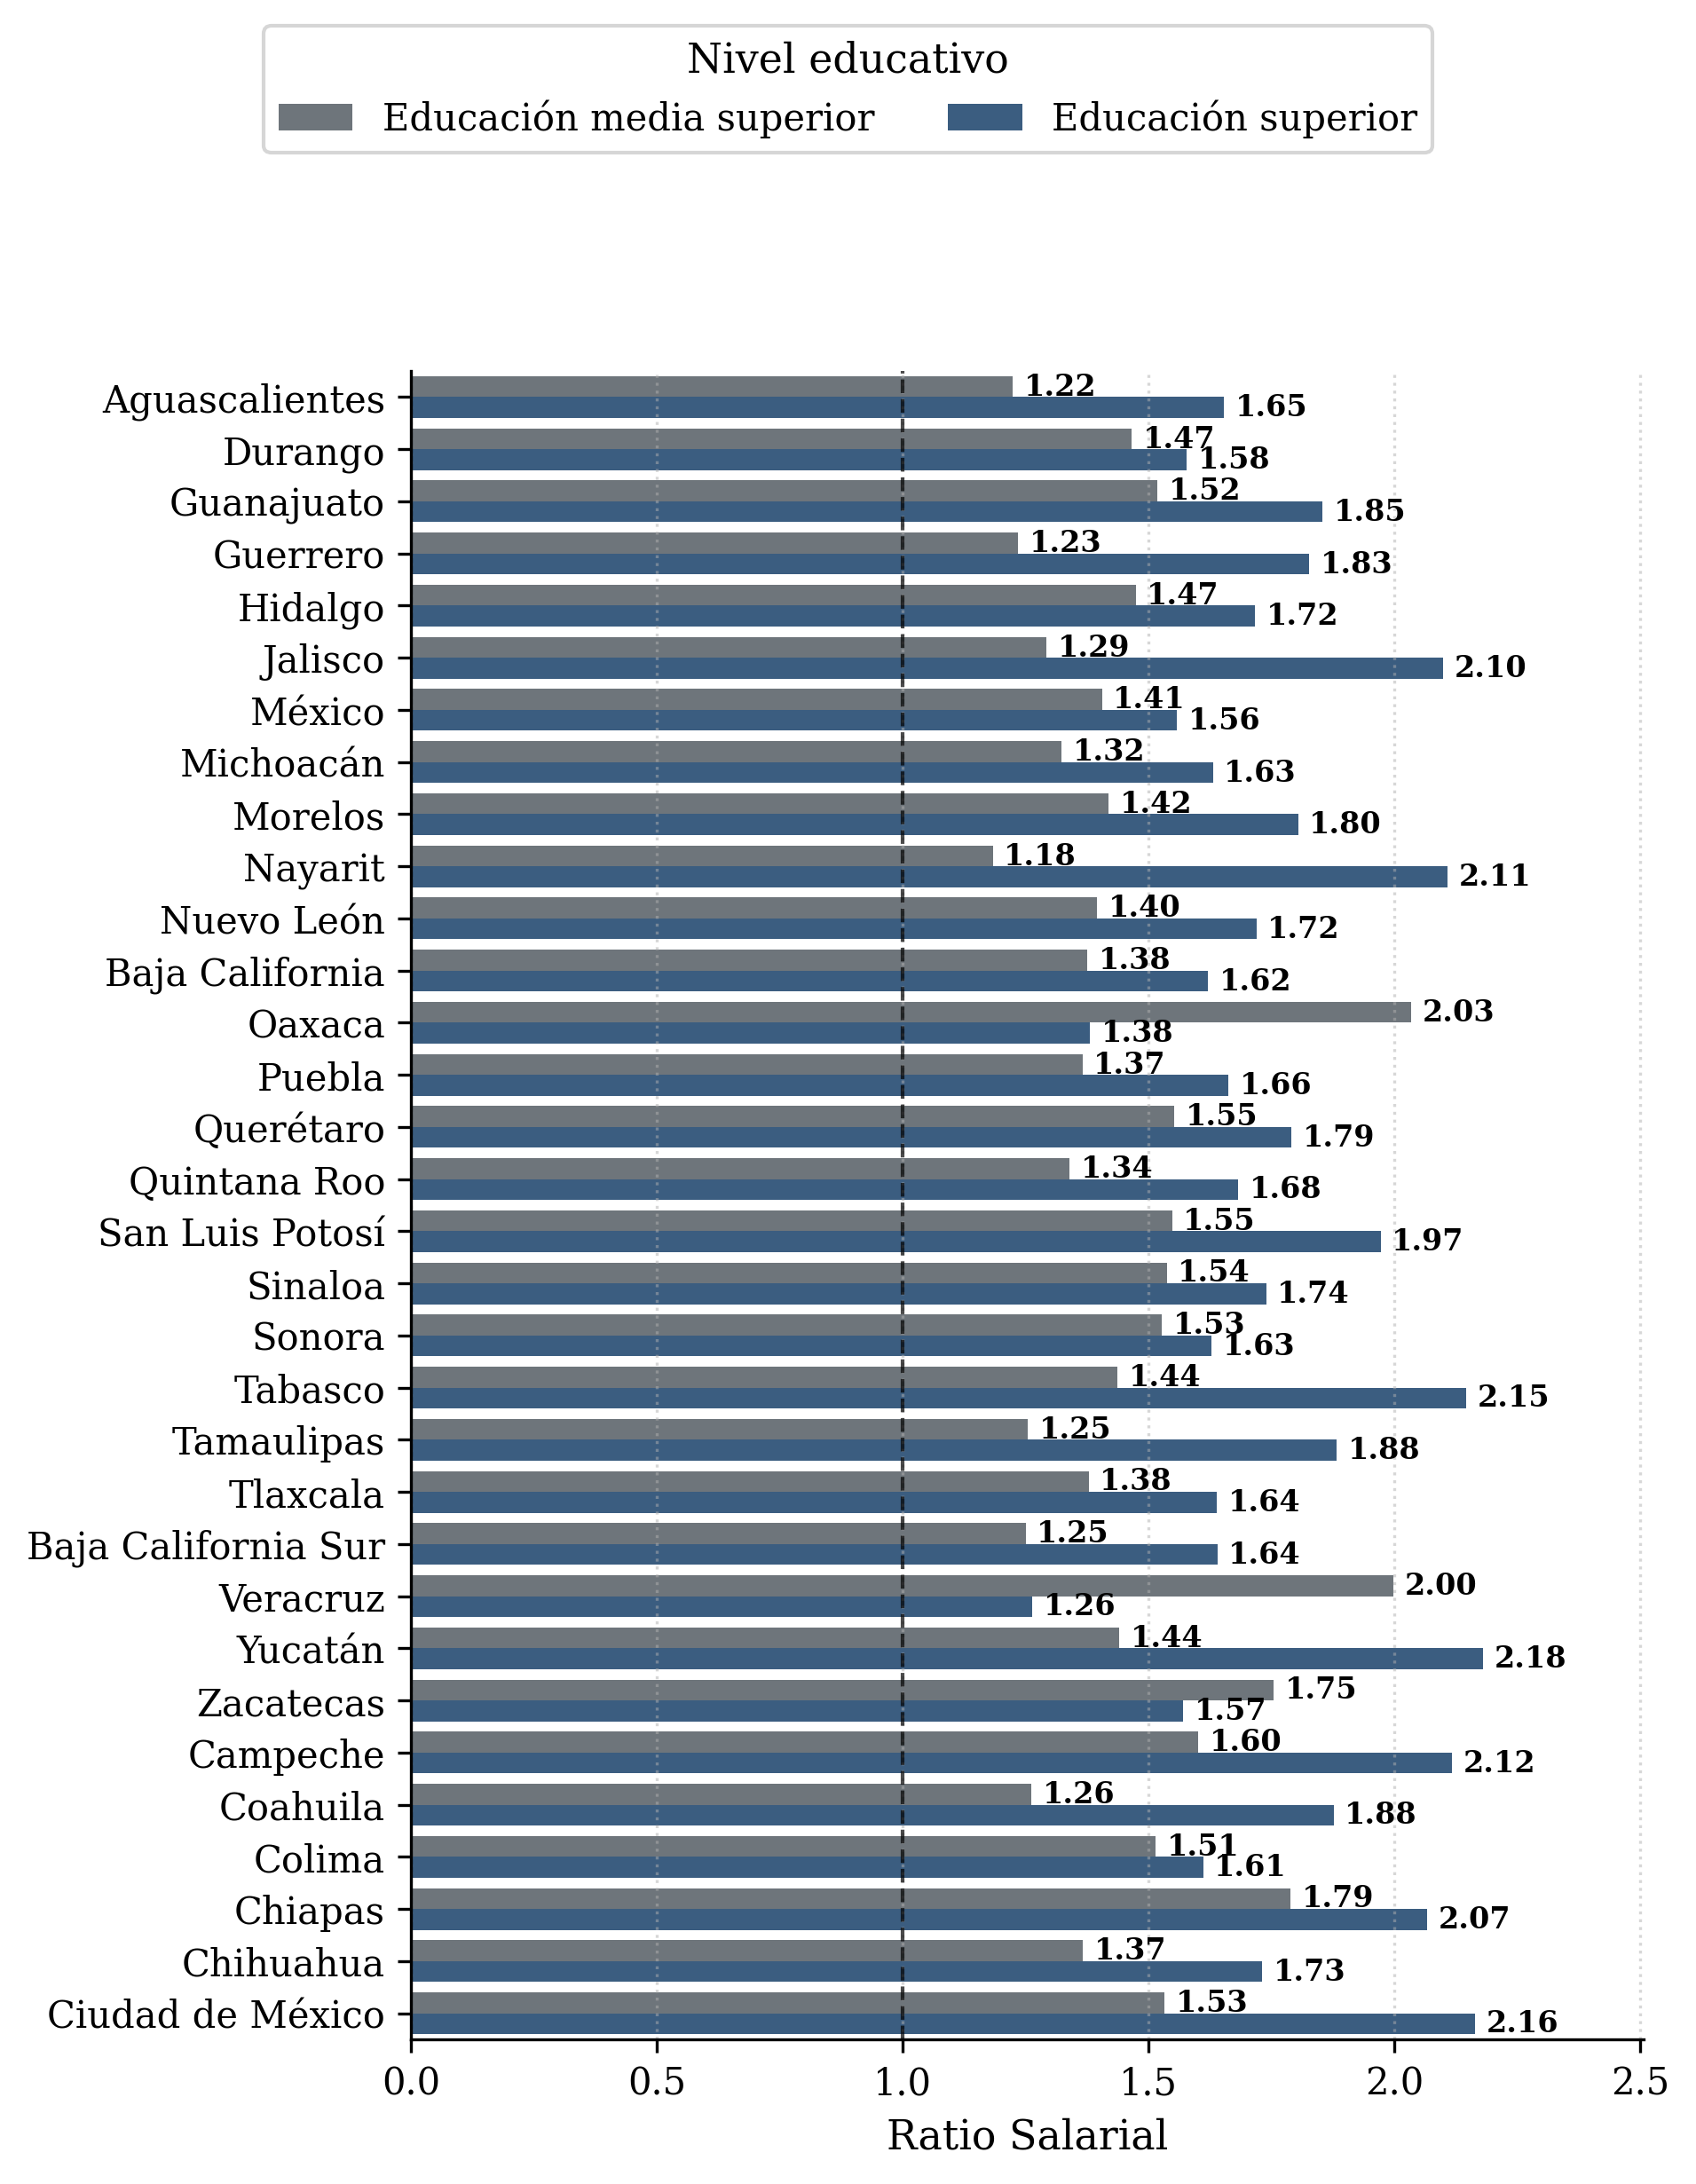

Figura 3.10 guardada para el año 2018.


/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_60842/2340052498.py:135: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.88])


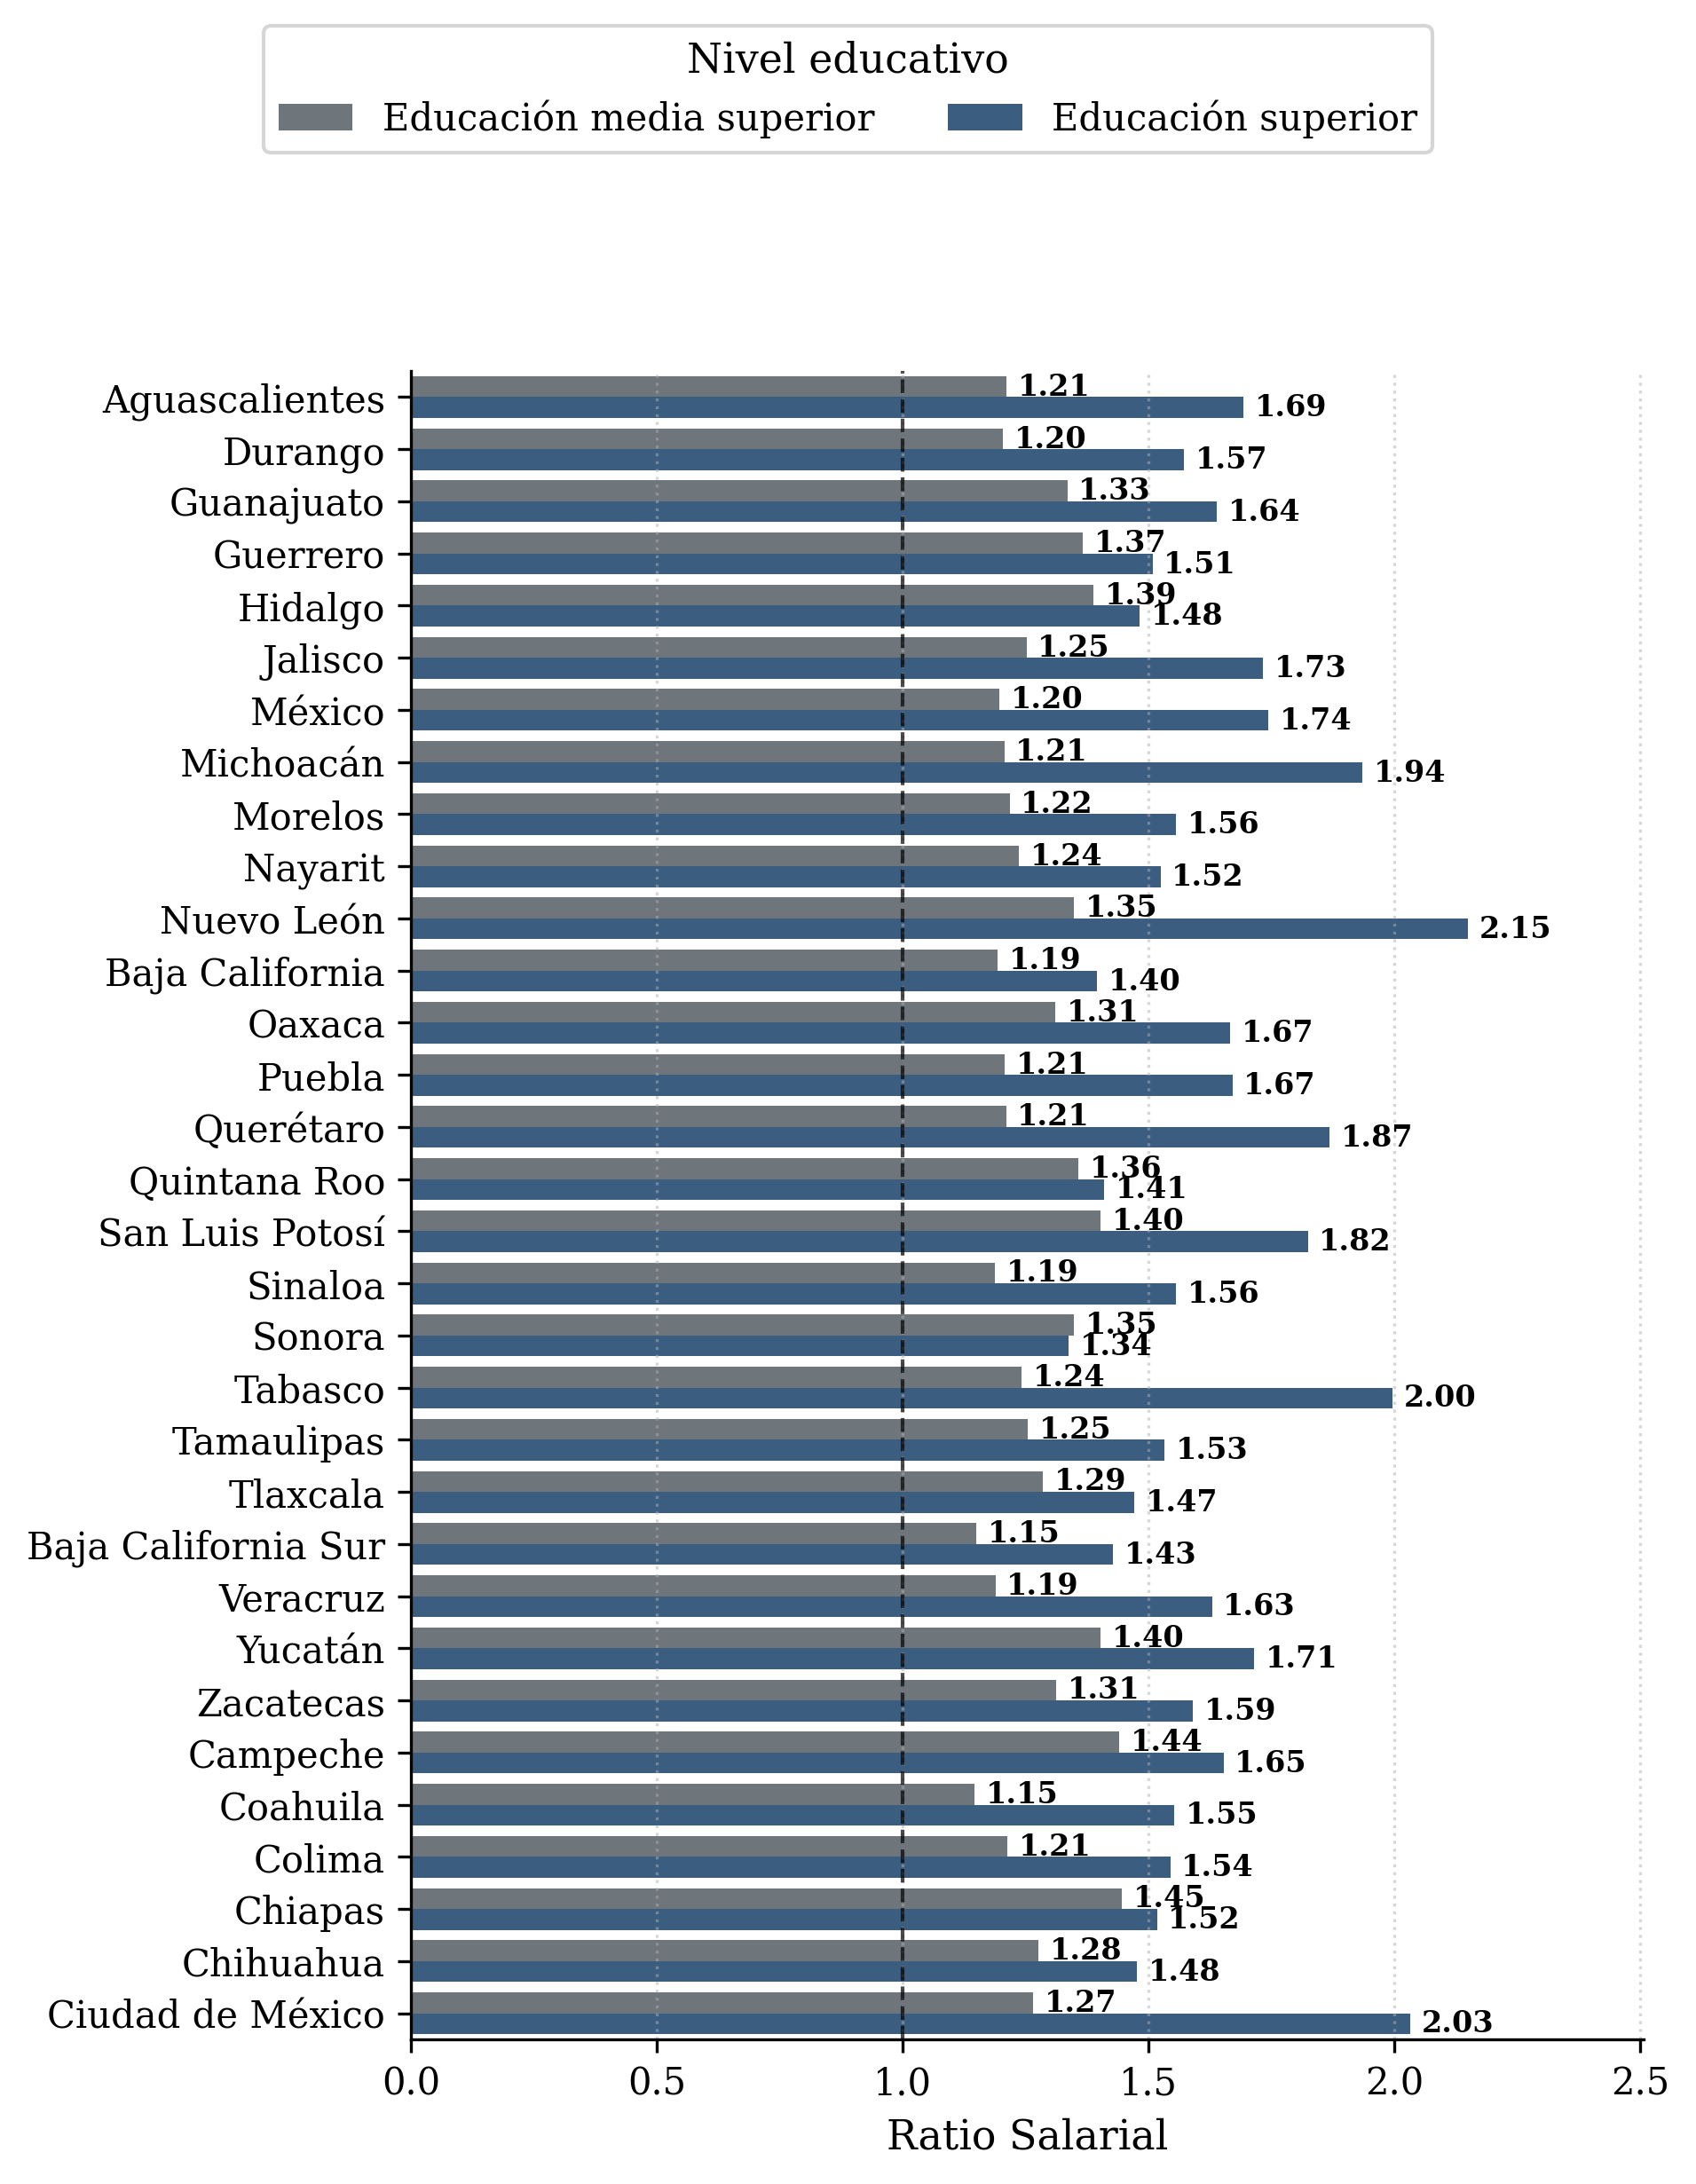

Figura 3.11 guardada para el año 2024.


In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================
# ESTILO UNIFICADO DE TESIS
# =============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# =============================================
# CARGA Y PREPARACIÓN DE DATOS
# =============================================
ruta = "data/processed/ratios_salariales_estatales.csv"
df = pd.read_csv(ruta)
df.columns = df.columns.str.strip()

# Diccionario de estados
estados_inegi = {
    1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur', 4: 'Campeche',
    5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua', 9: 'Ciudad de México',
    10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero', 13: 'Hidalgo', 14: 'Jalisco',
    15: 'México', 16: 'Michoacán', 17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León',
    20: 'Oaxaca', 21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
    25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas', 29: 'Tlaxcala',
    30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas'
}
df['Nombre_Entidad'] = df['entidad'].map(estados_inegi)

cols_ratios = ['ratio_ems', 'ratio_superior']

# Escala común para ambos años
max_valor_global = df[cols_ratios].max().max()

# Colores fijos para las dos categorías (en orden: primero ratio_ems, segundo ratio_superior)
paleta_fija = {'ratio_ems': '#6C757D', 'ratio_superior': '#2F5D8C'}

# =============================================
# GENERACIÓN DE FIGURAS POR AÑO
# =============================================
# Definir años y números de figura correspondientes
anios_a_graficar = [
    {'anio': 2018, 'fig_num': '3.10'},
    {'anio': 2024, 'fig_num': '3.11'}
]

output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

for item in anios_a_graficar:
    anio = item['anio']
    fig_num = item['fig_num']

    # Filtrar y preparar datos
    df_anio = df[df['anio'] == anio].copy()
    df_melted = df_anio.melt(
        id_vars=['Nombre_Entidad'],
        value_vars=cols_ratios,
        var_name='Nivel Educativo',
        value_name='Ratio Salarial'
    )

    # Crear figura con tamaño adecuado para muchas barras
    fig, ax = plt.subplots(figsize=(6.5, 8), constrained_layout=True)

    # Gráfico de barras horizontales con seaborn
    sns.barplot(
        data=df_melted,
        x='Ratio Salarial',
        y='Nombre_Entidad',
        hue='Nivel Educativo',
        palette=paleta_fija,
        ax=ax
    )

    # Línea de referencia en x=1
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.7)

    # Etiquetas de los ejes
    ax.set_xlabel('Ratio Salarial')
    ax.set_ylabel('')  # Sin etiqueta en Y

    # Fijar escala común
    ax.set_xlim(0, max_valor_global * 1.15)

    # Rejilla en el eje X (valores)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

    # Eliminar spines superiores y derecho
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



    # Agregar etiquetas numéricas a las barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f',
            padding=3,
            fontsize=8,
            fontweight='bold'
        )

    # =============================================
    # LEYENDA GENERAL (ARRIBA)
    # =============================================
    handles, labels = ax.get_legend_handles_labels()

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # =============================================
    # LEYENDA GENERAL (ARRIBA)
    # =============================================
    fig.legend(
        handles,
        ['Educación media superior', 'Educación superior'],
        title='Nivel educativo',
        ncol=2,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.03),
        frameon=True
    )

    # Dejar espacio para la leyenda
    fig.tight_layout(rect=[0, 0, 1, 0.88])

    # Guardar en PDF y SVG
    plt.savefig(os.path.join(output_dir, f'Figura_{fig_num}.pdf'), bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'Figura_{fig_num}.svg'), bbox_inches='tight')

    # Mostrar (opcional)
    plt.show()

    print(f"Figura {fig_num} guardada para el año {anio}.")

✅ Datos cargados.
✅ Datos procesados.


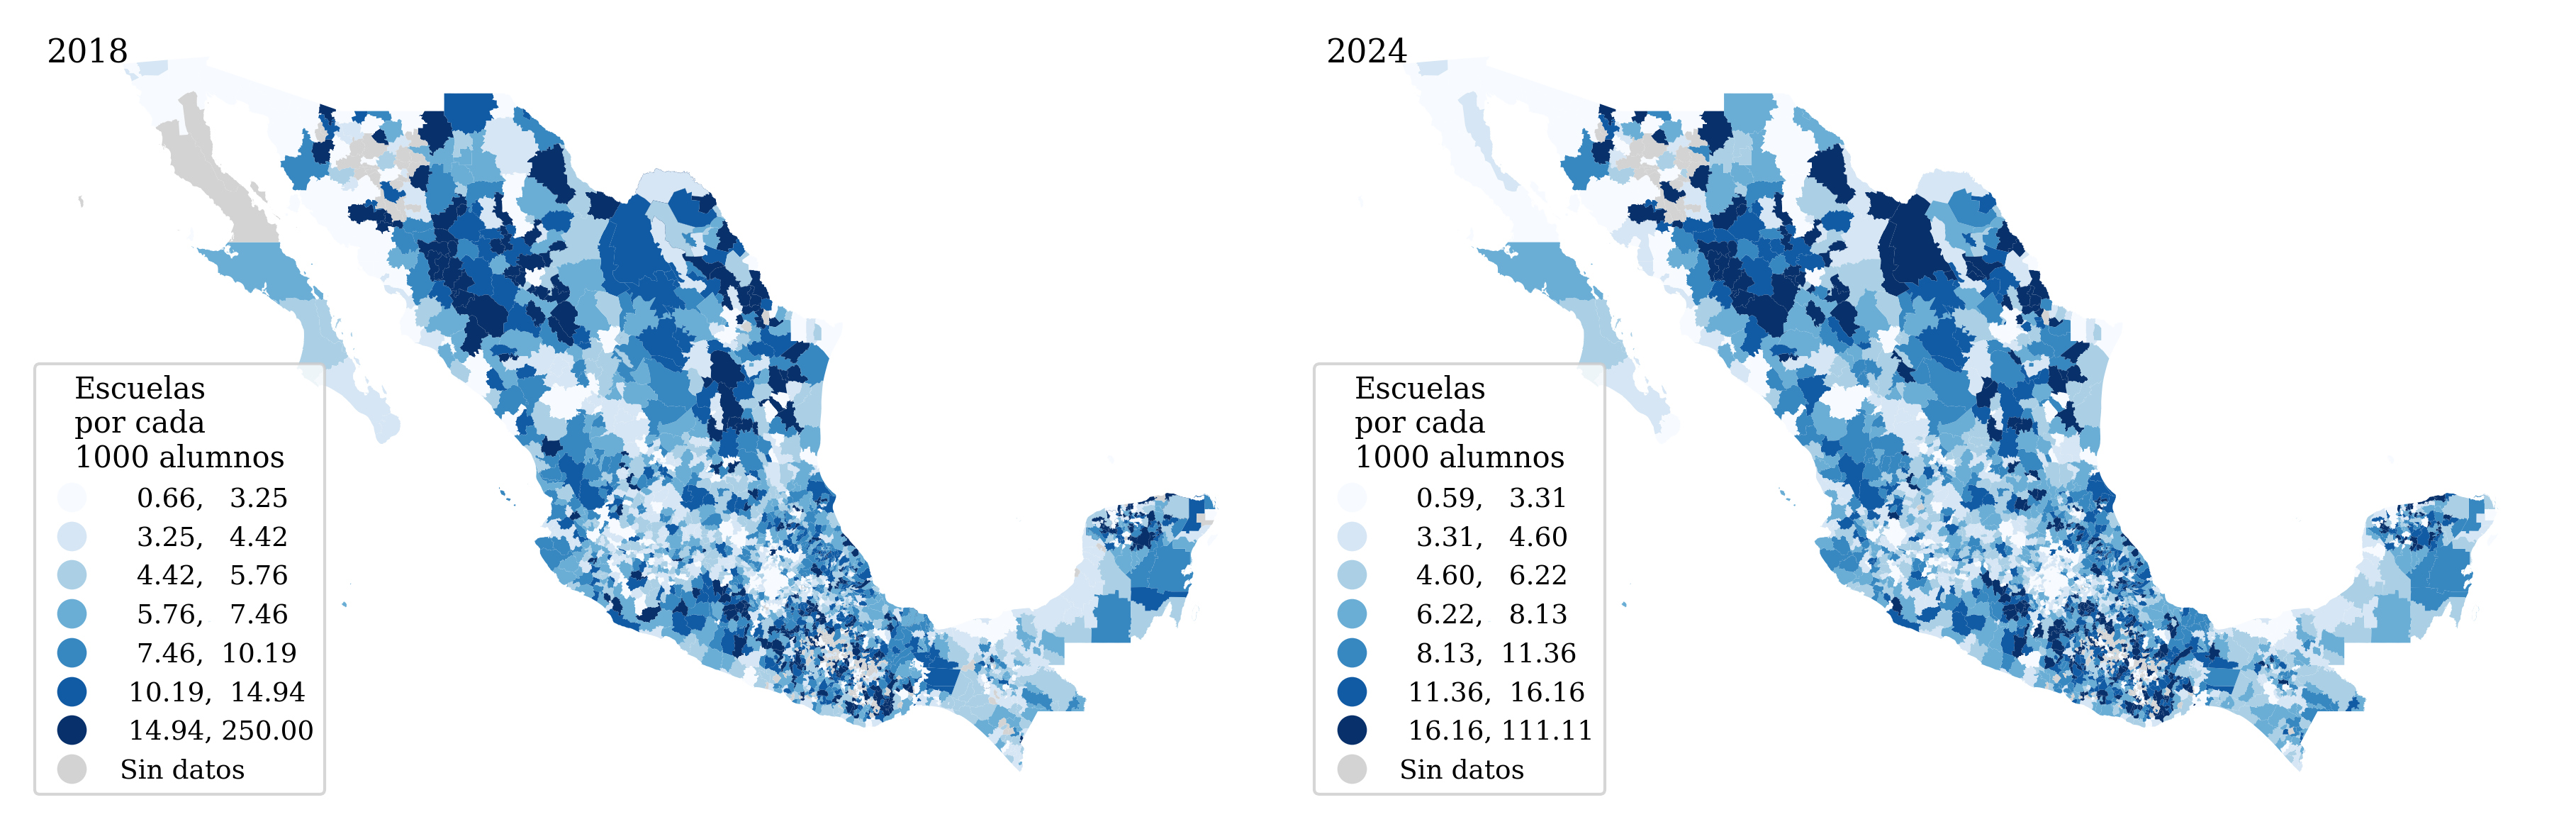

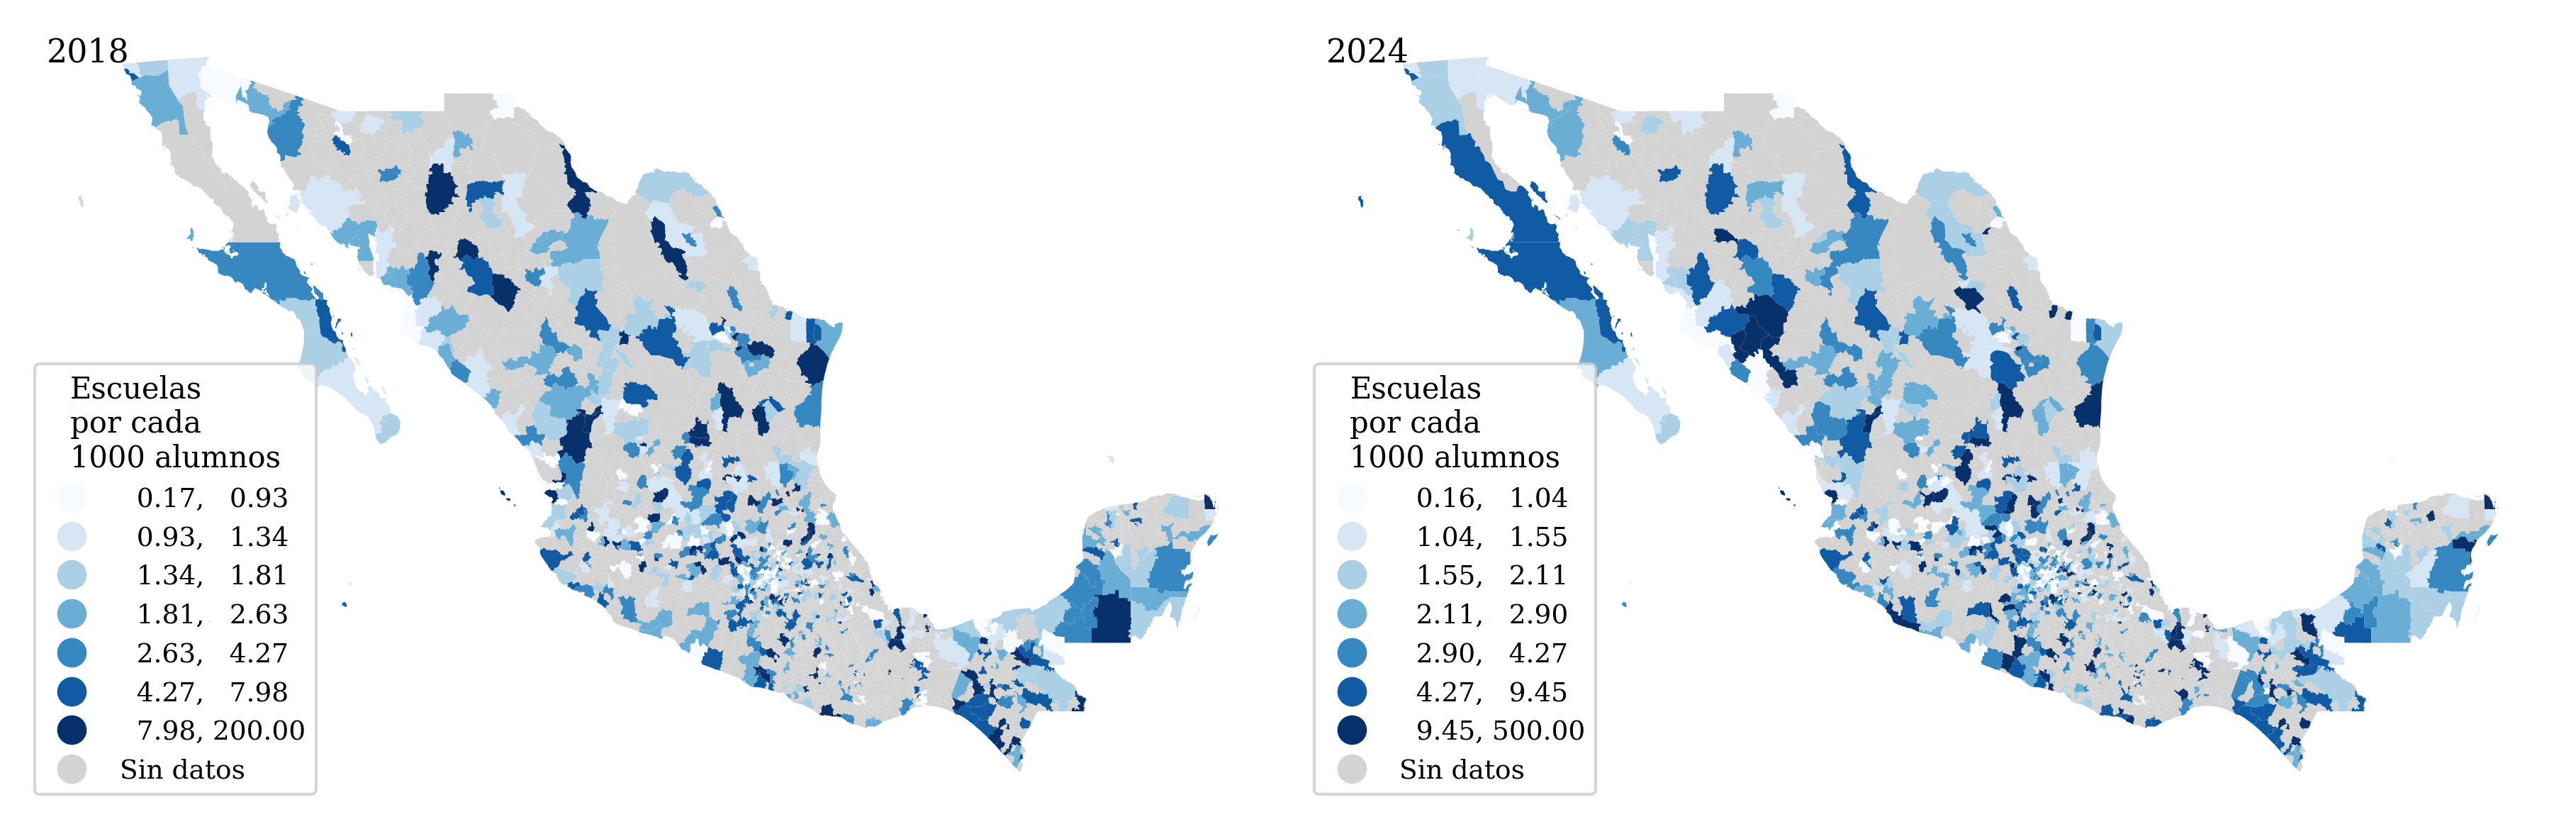

✅ Mapas guardados como Figuras 4.10 y 4.11.


In [17]:
# ============================================================
# MAPAS: ESCUELAS POR CADA 1000 ALUMNOS
# (Media Superior y Superior, 2018 vs 2024)
# Versión adaptada al estilo unificado de tesis
# ============================================================

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ESTILO UNIFICADO DE TESIS
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# ============================================================
# CARGA DE DATOS
# ============================================================
ruta_base = "data/processed/mapas"
ruta_mapa = "data/processed/mapas"

df_media_superior_2018 = pd.read_csv(
    f"{ruta_base}/media_superior_2018.csv", encoding="latin1"
)
df_media_superior_2024 = pd.read_csv(
    f"{ruta_base}/media_superior_2024.csv", encoding="latin1"
)
df_superior_2018 = pd.read_csv(
    f"{ruta_base}/superior_2018.csv", encoding="latin1"
)
df_superior_2024 = pd.read_csv(
    f"{ruta_base}/superior_2024.csv", encoding="latin1"
)

mx = gpd.read_file(ruta_mapa)
print("✅ Datos cargados.")

# ============================================================
# PROCESAMIENTO DE DATOS
# ============================================================
col_alumnos = "Alumnos"
col_escuelas = "Escuelas"
col_geo_datos = "ubicageo"
col_geo_mapa = "CVEGEO"

def procesar_dataframe(df):
    df[col_alumnos] = pd.to_numeric(df[col_alumnos], errors="coerce")
    df[col_escuelas] = pd.to_numeric(df[col_escuelas], errors="coerce")
    df["razon_alumnos_escuelas"] = np.where(
        df[col_escuelas] > 0,
        df[col_alumnos] / df[col_escuelas],
        np.nan
    )
    df["razon_escuelas_inv"] = np.where(
        df["razon_alumnos_escuelas"] > 0,
        (1 / df["razon_alumnos_escuelas"]) * 1000,
        np.nan
    )
    df[col_geo_datos] = pd.to_numeric(df[col_geo_datos], errors="coerce").astype("Int64")
    return df

df_media_superior_2018 = procesar_dataframe(df_media_superior_2018)
df_media_superior_2024 = procesar_dataframe(df_media_superior_2024)
df_superior_2018 = procesar_dataframe(df_superior_2018)
df_superior_2024 = procesar_dataframe(df_superior_2024)

mx[col_geo_mapa] = pd.to_numeric(mx[col_geo_mapa], errors="coerce").astype("Int64")
print("✅ Datos procesados.")

# ============================================================
# FUNCIÓN PARA GRAFICAR UN PANEL
# ============================================================
def graficar_en_eje(mapa_base, datos_df, columna, ax):
    mapa = mapa_base.merge(
        datos_df,
        left_on=col_geo_mapa,
        right_on=col_geo_datos,
        how="left"
    )
    mapa.plot(
        column=columna,
        cmap="Blues",                     # Paleta armónica con #2F5D8C
        scheme="quantiles",
        k=7,
        legend=True,
        ax=ax,
        legend_kwds={
            "loc": "lower left",
            "fontsize": 9,
            "frameon": True,
            "title": "Escuelas\npor cada\n1000 alumnos",
            "title_fontsize": 10
        },
        missing_kwds={
            "color": "lightgrey",
            "label": "Sin datos"
        }
    )
    # Sin título en el subplot (eliminado)
    ax.set_axis_off()

# ============================================================
# GENERACIÓN DE FIGURAS (4.10 y 4.11)
# ============================================================
output_dir = "outputs/figures"
os.makedirs(output_dir, exist_ok=True)

# --- Figura 4.10: Media Superior ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

graficar_en_eje(mx, df_media_superior_2018, "razon_escuelas_inv", ax1)
graficar_en_eje(mx, df_media_superior_2024, "razon_escuelas_inv", ax2)

# Añadir etiquetas de año de forma manual (sin título)
ax1.text(0.02, 0.98, "2018", transform=ax1.transAxes, fontsize=11, va='top', ha='left')
ax2.text(0.02, 0.98, "2024", transform=ax2.transAxes, fontsize=11, va='top', ha='left')

plt.savefig(os.path.join(output_dir, "Figura_4.10.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, "Figura_4.10.svg"), bbox_inches='tight')
plt.show()

# --- Figura 4.11: Superior ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

graficar_en_eje(mx, df_superior_2018, "razon_escuelas_inv", ax1)
graficar_en_eje(mx, df_superior_2024, "razon_escuelas_inv", ax2)

ax1.text(0.02, 0.98, "2018", transform=ax1.transAxes, fontsize=11, va='top', ha='left')
ax2.text(0.02, 0.98, "2024", transform=ax2.transAxes, fontsize=11, va='top', ha='left')

plt.savefig(os.path.join(output_dir, "Figura_4.11.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(output_dir, "Figura_4.11.svg"), bbox_inches='tight')
plt.show()

print("✅ Mapas guardados como Figuras 4.10 y 4.11.")

✅ Datos cargados.
Municipios encontrados: 2475
✅ Mapa estatal creado.
Estados: 32
✅ Datos educativos agregados a nivel estatal.


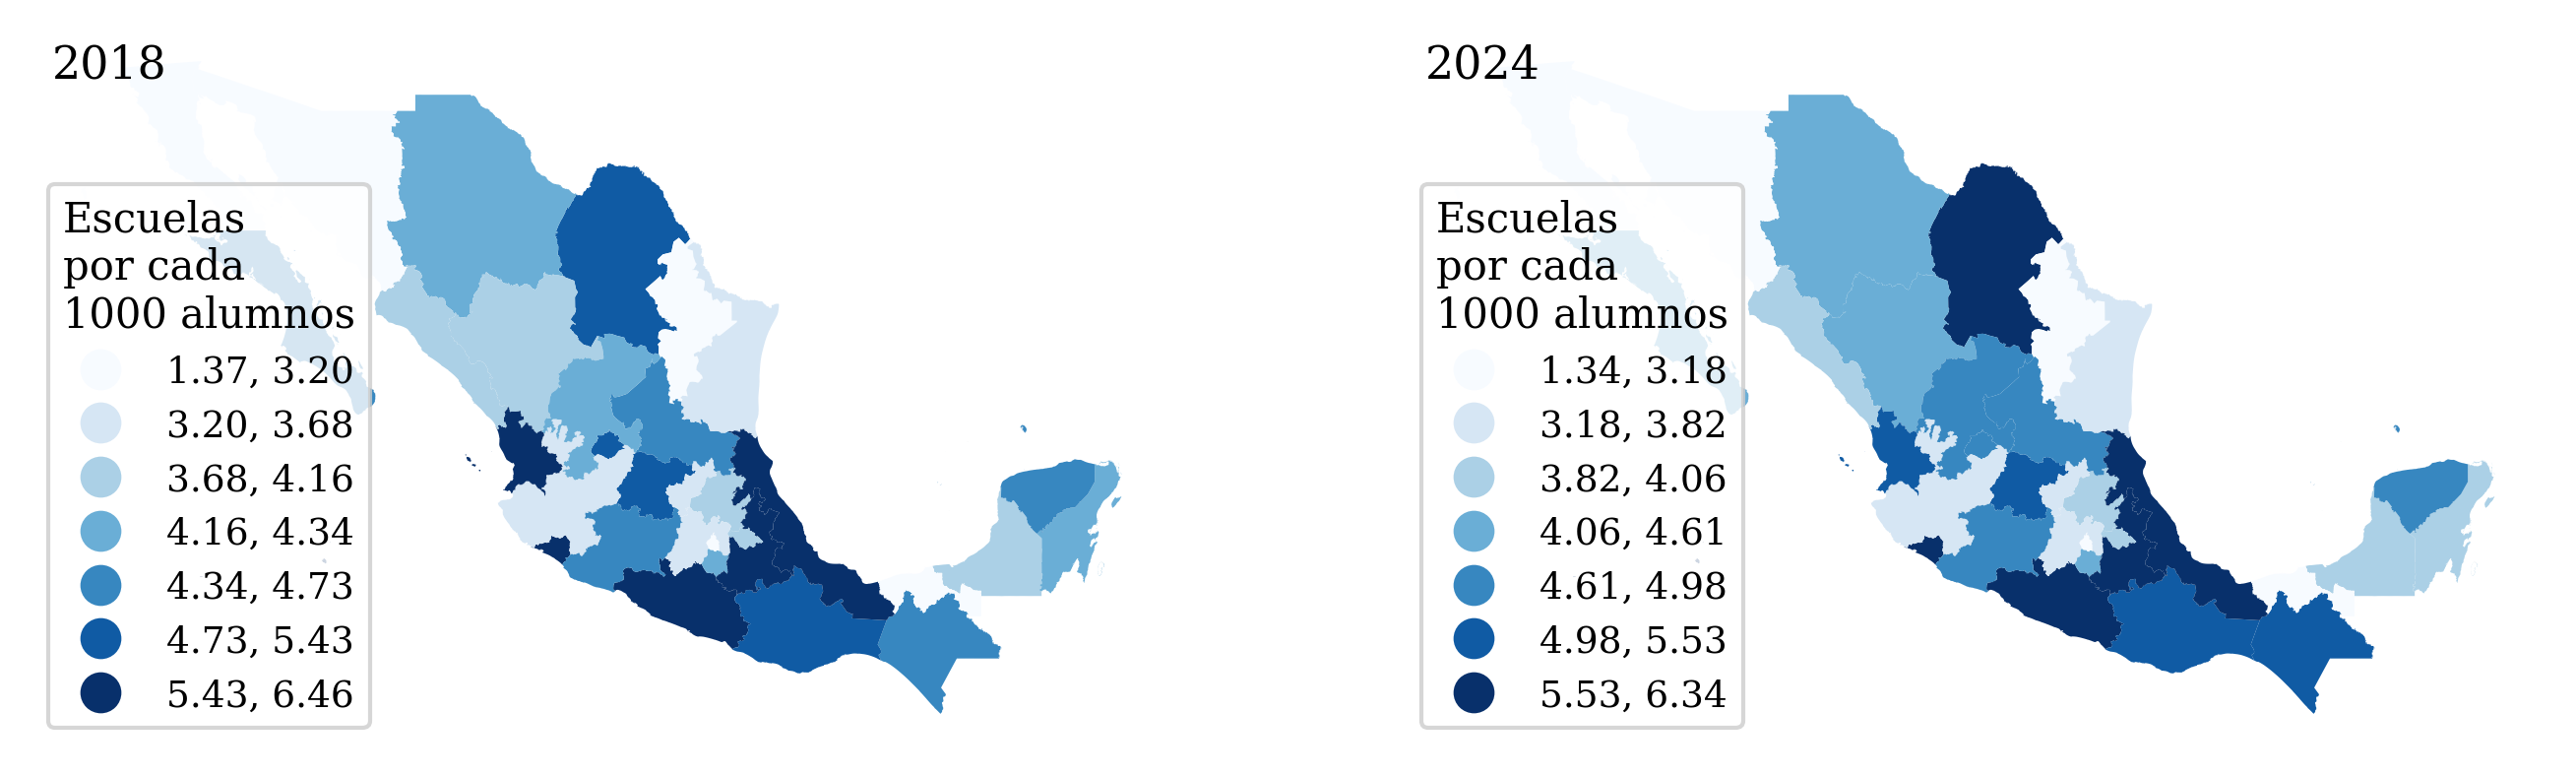

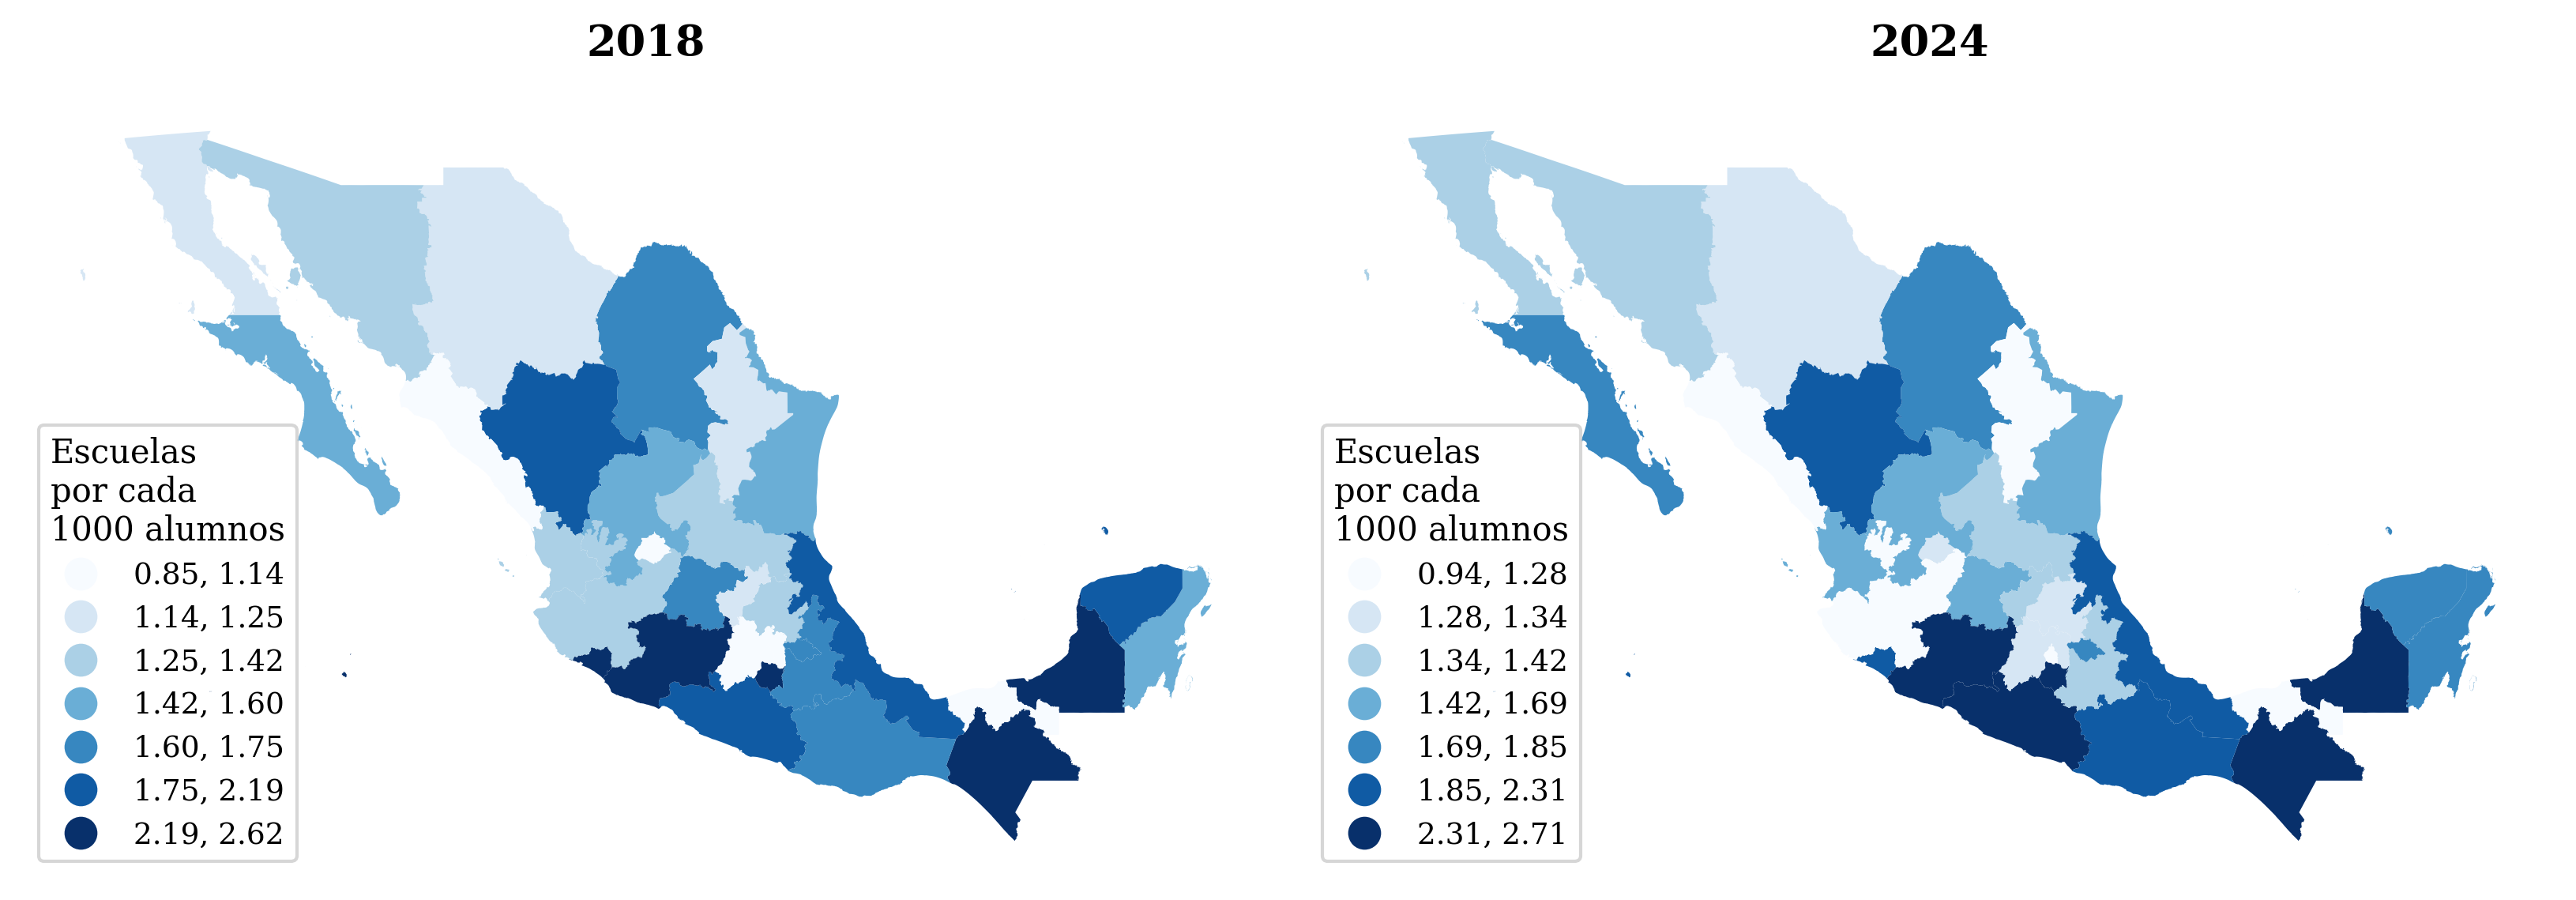

✅ Mapas estatales generados correctamente.


In [55]:
# ============================================================
# MAPAS ESTATALES: ESCUELAS POR CADA 1000 ALUMNOS
# (Media Superior y Superior, 2018 vs 2024)
# Construcción estatal desde shapefile municipal
# ============================================================

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# ESTILO UNIFICADO DE TESIS
# ------------------------------------------------------------

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.dpi': 300
})


# ------------------------------------------------------------
# CARGA DE DATOS
# ------------------------------------------------------------

ruta_base = "data/processed/mapas"
ruta_mapa = "data/processed/mapas"


df_media_superior_2018 = pd.read_csv(
    f"{ruta_base}/media_superior_2018.csv",
    encoding="latin1"
)

df_media_superior_2024 = pd.read_csv(
    f"{ruta_base}/media_superior_2024.csv",
    encoding="latin1"
)

df_superior_2018 = pd.read_csv(
    f"{ruta_base}/superior_2018.csv",
    encoding="latin1"
)

df_superior_2024 = pd.read_csv(
    f"{ruta_base}/superior_2024.csv",
    encoding="latin1"
)


# Cargar shapefile municipal
mx = gpd.read_file(ruta_mapa)

print("✅ Datos cargados.")
print("Municipios encontrados:", len(mx))


# ------------------------------------------------------------
# CONVERTIR SHAPEFILE MUNICIPAL A ESTATAL
# ------------------------------------------------------------

mx['CVEGEO'] = pd.to_numeric(
    mx['CVEGEO'],
    errors='coerce'
).astype('Int64')


# Extraer clave estatal
mx['clave_estado'] = (
    mx['CVEGEO']
    .astype(str)
    .str.zfill(5)
    .str[:2]
    .astype(int)
)


# Disolver municipios en estados
mx_estatal = mx.dissolve(
    by='clave_estado',
    as_index=False
)


print("✅ Mapa estatal creado.")
print("Estados:", len(mx_estatal))



# ------------------------------------------------------------
# AGREGAR DATOS MUNICIPALES A ESTATAL
# ------------------------------------------------------------

def agregar_estatal(df):

    df = df.copy()

    df['ubicageo'] = pd.to_numeric(
        df['ubicageo'],
        errors='coerce'
    )

    df['Alumnos'] = pd.to_numeric(
        df['Alumnos'],
        errors='coerce'
    )

    df['Escuelas'] = pd.to_numeric(
        df['Escuelas'],
        errors='coerce'
    )


    df = df.dropna(
        subset=['ubicageo']
    )


    df['ubicageo'] = df['ubicageo'].astype(int)


    # clave estatal desde clave municipal
    df['clave_estado'] = (
        df['ubicageo']
        .astype(str)
        .str.zfill(5)
        .str[:2]
        .astype(int)
    )


    df_estado = (
        df.groupby('clave_estado', as_index=False)
        .agg({
            'Alumnos':'sum',
            'Escuelas':'sum'
        })
    )


    # Escuelas por cada 1000 alumnos
    df_estado['razon_escuelas_inv'] = np.where(
        df_estado['Alumnos'] > 0,
        (df_estado['Escuelas'] / df_estado['Alumnos']) * 1000,
        np.nan
    )


    return df_estado



df_media_superior_2018 = agregar_estatal(
    df_media_superior_2018
)

df_media_superior_2024 = agregar_estatal(
    df_media_superior_2024
)

df_superior_2018 = agregar_estatal(
    df_superior_2018
)

df_superior_2024 = agregar_estatal(
    df_superior_2024
)


print("✅ Datos educativos agregados a nivel estatal.")



# ------------------------------------------------------------
# FUNCIÓN DE MAPA
# ------------------------------------------------------------

def graficar_en_eje(
    mapa_base,
    datos_df,
    columna,
    ax
):

    mapa = mapa_base.merge(
        datos_df,
        on='clave_estado',
        how='left'
    )


    mapa.plot(
        column=columna,
        cmap='Blues',
        scheme='quantiles',
        k=7,
        legend=True,
        ax=ax,

        legend_kwds={
            'loc':'lower left',
            'fontsize':9,
            'frameon':True,
            'title':'Escuelas\npor cada\n1000 alumnos',
            'title_fontsize':10
        },

        missing_kwds={
            'color':'lightgrey',
            'label':'Sin datos'
        }
    )


    ax.set_axis_off()



# ------------------------------------------------------------
# EXPORTACIÓN
# ------------------------------------------------------------

output_dir = "outputs/figures"

os.makedirs(
    output_dir,
    exist_ok=True
)



# ============================================================
# FIGURA 4.10
# MEDIA SUPERIOR
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(11,5)
)


graficar_en_eje(
    mx_estatal,
    df_media_superior_2018,
    'razon_escuelas_inv',
    ax1
)


graficar_en_eje(
    mx_estatal,
    df_media_superior_2024,
    'razon_escuelas_inv',
    ax2
)


ax1.text(
    0.02,
    0.98,
    '2018',
    transform=ax1.transAxes,
    fontsize=11,
    va='top'
)


ax2.text(
    0.02,
    0.98,
    '2024',
    transform=ax2.transAxes,
    fontsize=11,
    va='top'
)


plt.savefig(
    os.path.join(output_dir,'Figura_4.10.pdf'),
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(output_dir,'Figura_4.10.svg'),
    bbox_inches='tight'
)

plt.show()



# ============================================================
# FIGURA 4.11
# SUPERIOR
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(11,5)
)


graficar_en_eje(
    mx_estatal,
    df_superior_2018,
    'razon_escuelas_inv',
    ax1
)


graficar_en_eje(
    mx_estatal,
    df_superior_2024,
    'razon_escuelas_inv',
    ax2
)


ax1.set_title("2018", pad=12)
ax2.set_title("2024", pad=12)

fig.tight_layout()

plt.savefig(
    os.path.join(output_dir,'Figura_4.11.pdf'),
    bbox_inches='tight'
)

plt.savefig(
    os.path.join(output_dir,'Figura_4.11.svg'),
    bbox_inches='tight'
)

plt.show()


print("✅ Mapas estatales generados correctamente.")